# Apparent Stability Is Not Safety
## Detecting Hidden High-Risk Patients Among Alert ED Arrivals

### Project Focus
This project investigates whether patients who appear stable at triage, especially those recorded as alert, may still carry high clinical risk.

### Why This Matters
In the emergency department, the most obvious critical patients are often recognized quickly. A more clinically valuable safety net is one that helps flag patients who appear stable at first glance but may still require urgent attention.

In [22]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve
)
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
from sklearn.ensemble import RandomForestClassifier

## Data Loading

We load the core competition files provided by Triagegeist: the training table, the test table, chief complaint records, and patient history records.

In [2]:
DATA_PATH = "/kaggle/input/competitions/triagegeist"

train = pd.read_csv(f"{DATA_PATH}/train.csv")
test = pd.read_csv(f"{DATA_PATH}/test.csv")
chief = pd.read_csv(f"{DATA_PATH}/chief_complaints.csv")
history = pd.read_csv(f"{DATA_PATH}/patient_history.csv")

print(train.shape, test.shape, chief.shape, history.shape)
train.head()

(80000, 40) (20000, 37) (100000, 3) (100000, 26)


,patient_id,site_id,triage_nurse_id,arrival_mode,arrival_hour,arrival_day,arrival_month,arrival_season,shift,age,...,gcs_total,pain_score,weight_kg,height_cm,bmi,shock_index,news2_score,disposition,ed_los_hours,triage_acuity
0,TG-UXRGA9UCO,SITE-TMP-01,NURSE-0033,walk-in,6,Monday,5,spring,morning,43,...,14,7,52.3,165.4,19.1,0.725,8,discharged,7.35,2
1,TG-B19DBBS2G,SITE-HEL-01,NURSE-0001,walk-in,6,Thursday,4,spring,morning,72,...,15,-1,73.3,164.4,27.1,0.739,1,discharged,0.70,5
2,TG-GZ97W7M6V,SITE-HEL-02,NURSE-0005,walk-in,8,Saturday,4,spring,morning,82,...,15,3,77.1,183.7,22.8,0.798,2,discharged,0.63,5
3,TG-THIB2TN9Q,SITE-HEL-02,NURSE-0026,police,7,Sunday,3,spring,morning,50,...,15,7,49.6,172.6,16.6,0.812,2,discharged,1.99,3
4,TG-J3U3LQ2QY,SITE-HEL-02,NURSE-0044,walk-in,5,Tuesday,5,spring,night,62,...,15,4,71.9,173.4,23.9,0.812,2,transferred,3.58,3


## Data Integration and Analytical Table Construction

We merge the structured triage table, chief complaint records, and patient history records by `patient_id` to construct the main patient-level analytical dataset.

In [3]:
# -------------------------
# Cell 1: Data integration
# -------------------------

DATA_PATH = "/kaggle/input/competitions/triagegeist"

train = pd.read_csv(f"{DATA_PATH}/train.csv")
test = pd.read_csv(f"{DATA_PATH}/test.csv")
chief = pd.read_csv(f"{DATA_PATH}/chief_complaints.csv")
history = pd.read_csv(f"{DATA_PATH}/patient_history.csv")

train_df = train.merge(chief, on="patient_id", how="left")
train_df = train_df.merge(history, on="patient_id", how="left")

test_df = test.merge(chief, on="patient_id", how="left")
test_df = test_df.merge(history, on="patient_id", how="left")

# Resolve duplicated complaint-system columns if identical
if "chief_complaint_system_x" in train_df.columns and "chief_complaint_system_y" in train_df.columns:
    same_ratio = (train_df["chief_complaint_system_x"] == train_df["chief_complaint_system_y"]).mean()
    print("chief_complaint_system same_ratio:", same_ratio)

    if same_ratio == 1.0:
        train_df["chief_complaint_system"] = train_df["chief_complaint_system_x"]
        test_df["chief_complaint_system"] = test_df["chief_complaint_system_x"]

        train_df = train_df.drop(columns=["chief_complaint_system_x", "chief_complaint_system_y"])
        test_df = test_df.drop(columns=["chief_complaint_system_x", "chief_complaint_system_y"])

# Keep an EDA copy so we do not accidentally mutate the modeling table later
eda_df = train_df.copy()

print("train:", train.shape)
print("test:", test.shape)
print("chief:", chief.shape)
print("history:", history.shape)
print("merged train_df:", eda_df.shape)
print("merged test_df :", test_df.shape)

display(eda_df.head())
print("\nColumns:")
print(eda_df.columns.tolist())

chief_complaint_system same_ratio: 1.0
train: (80000, 40)
test: (20000, 37)
chief: (100000, 3)
history: (100000, 26)
merged train_df: (80000, 66)
merged test_df : (20000, 63)


,patient_id,site_id,triage_nurse_id,arrival_mode,arrival_hour,arrival_day,arrival_month,arrival_season,shift,age,...,hx_hyperthyroidism,hx_hiv,hx_coagulopathy,hx_immunosuppressed,hx_pregnant,hx_substance_use_disorder,hx_coronary_artery_disease,hx_stroke_prior,hx_peripheral_vascular_disease,chief_complaint_system
0,TG-UXRGA9UCO,SITE-TMP-01,NURSE-0033,walk-in,6,Monday,5,spring,morning,43,...,1,0,0,1,0,0,0,0,0,neurological
1,TG-B19DBBS2G,SITE-HEL-01,NURSE-0001,walk-in,6,Thursday,4,spring,morning,72,...,0,0,0,1,0,1,1,0,0,genitourinary
2,TG-GZ97W7M6V,SITE-HEL-02,NURSE-0005,walk-in,8,Saturday,4,spring,morning,82,...,1,1,0,0,0,0,1,1,1,other
3,TG-THIB2TN9Q,SITE-HEL-02,NURSE-0026,police,7,Sunday,3,spring,morning,50,...,0,1,0,1,0,0,0,0,1,dermatological
4,TG-J3U3LQ2QY,SITE-HEL-02,NURSE-0044,walk-in,5,Tuesday,5,spring,night,62,...,1,0,1,1,0,1,1,1,0,dermatological



Columns:
['patient_id', 'site_id', 'triage_nurse_id', 'arrival_mode', 'arrival_hour', 'arrival_day', 'arrival_month', 'arrival_season', 'shift', 'age', 'age_group', 'sex', 'language', 'insurance_type', 'transport_origin', 'pain_location', 'mental_status_triage', 'num_prior_ed_visits_12m', 'num_prior_admissions_12m', 'num_active_medications', 'num_comorbidities', 'systolic_bp', 'diastolic_bp', 'mean_arterial_pressure', 'pulse_pressure', 'heart_rate', 'respiratory_rate', 'temperature_c', 'spo2', 'gcs_total', 'pain_score', 'weight_kg', 'height_cm', 'bmi', 'shock_index', 'news2_score', 'disposition', 'ed_los_hours', 'triage_acuity', 'chief_complaint_raw', 'hx_hypertension', 'hx_diabetes_type2', 'hx_diabetes_type1', 'hx_asthma', 'hx_copd', 'hx_heart_failure', 'hx_atrial_fibrillation', 'hx_ckd', 'hx_liver_disease', 'hx_malignancy', 'hx_obesity', 'hx_depression', 'hx_anxiety', 'hx_dementia', 'hx_epilepsy', 'hx_hypothyroidism', 'hx_hyperthyroidism', 'hx_hiv', 'hx_coagulopathy', 'hx_immunosupp

## Target Distribution and High-Risk Definition

We first examine the distribution of `triage_acuity` and define a binary high-risk target (`triage_acuity <= 2`).

In the training data, 20.8% of patients belong to the high-risk group, while the majority fall into lower-acuity categories. This shows that urgent cases are clinically important but relatively less frequent, which motivates recall-focused evaluation.

Triage acuity count:


,count
triage_acuity,
1,3222
2,13439
3,28921
4,23020
5,11398



Triage acuity ratio:


,ratio
triage_acuity,
1,0.0403
2,0.1680
3,0.3615
4,0.2878
5,0.1425



High-risk ratio (triage_acuity <= 2): 0.2083


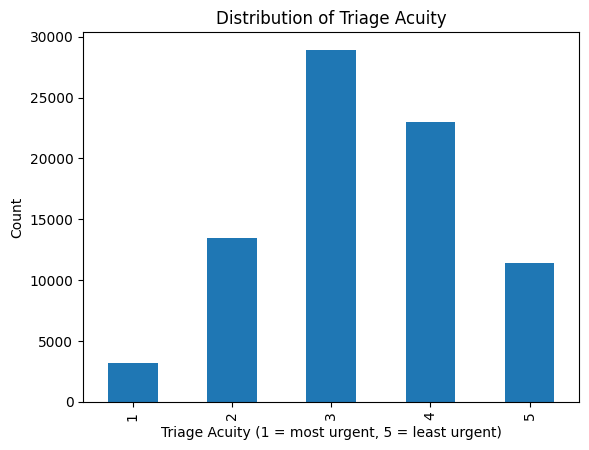

In [4]:
# -------------------------
# Cell 2: Target distribution
# -------------------------

eda_df["high_risk"] = (eda_df["triage_acuity"] <= 2).astype(int)

target_count = eda_df["triage_acuity"].value_counts().sort_index()
target_ratio = eda_df["triage_acuity"].value_counts(normalize=True).sort_index().round(4)

print("Triage acuity count:")
display(target_count.to_frame("count"))

print("\nTriage acuity ratio:")
display(target_ratio.to_frame("ratio"))

print("\nHigh-risk ratio (triage_acuity <= 2):", round(eda_df["high_risk"].mean(), 4))

target_count.plot(kind="bar")
plt.title("Distribution of Triage Acuity")
plt.xlabel("Triage Acuity (1 = most urgent, 5 = least urgent)")
plt.ylabel("Count")
plt.show()

## Missingness and Data Quality Patterns

We inspect missingness across key variables to understand whether absent measurements may themselves carry clinical or workflow-related signal.

Missingness is concentrated in a small set of vital-sign variables, especially blood pressure and respiratory rate. Importantly, these missing values are not randomly distributed across acuity levels: missing blood pressure and respiratory rate measurements appear almost exclusively in lower-acuity patients (levels 4-5), while no such missingness is observed in the highest-acuity groups. This suggests that missingness may partly reflect triage workflow rather than pure data noise, and should therefore be interpreted carefully in later modeling.

In [5]:
# -------------------------
# Cell 3: Missingness
# -------------------------

missing_rate = eda_df.isna().mean().sort_values(ascending=False)
missing_rate = missing_rate[missing_rate > 0].round(4)

print("Top missing columns:")
display(missing_rate.head(20).to_frame("missing_rate"))

if "pain_score" in eda_df.columns:
    print("pain_score == -1 ratio:", round((eda_df["pain_score"] == -1).mean(), 4))

missing_signal_cols = [
    c for c in ["systolic_bp", "diastolic_bp", "heart_rate", "respiratory_rate", "temperature_c", "spo2"]
    if c in eda_df.columns
]

for col in missing_signal_cols:
    miss_col = f"{col}_missing"
    eda_df[miss_col] = eda_df[col].isna().astype(int)

    print(f"\n[{col}] missing rate by triage_acuity")
    display(eda_df.groupby("triage_acuity")[miss_col].mean().round(4).to_frame("missing_rate"))

    print(f"[{col}] high-risk ratio by missingness")
    display(eda_df.groupby(miss_col)["high_risk"].mean().round(4).to_frame("high_risk_ratio"))

Top missing columns:


,missing_rate
systolic_bp,0.0518
pulse_pressure,0.0518
mean_arterial_pressure,0.0518
diastolic_bp,0.0518
shock_index,0.0518
respiratory_rate,0.0383
temperature_c,0.0072


pain_score == -1 ratio: 0.1394

[systolic_bp] missing rate by triage_acuity


,missing_rate
triage_acuity,
1,0.0000
2,0.0000
3,0.0000
4,0.1215
5,0.1184


[systolic_bp] high-risk ratio by missingness


...

,high_risk_ratio
temperature_c_missing,
0,0.2098
1,0.0000



[spo2] missing rate by triage_acuity


,missing_rate
triage_acuity,
1,0.0
2,0.0
3,0.0
4,0.0
5,0.0


[spo2] high-risk ratio by missingness


,high_risk_ratio
spo2_missing,
0,0.2083


## Clinical Signal Exploration

We examine how core physiological variables differ across acuity levels in order to confirm that the dataset reflects clinically plausible severity patterns.

The physiological gradients are strong and clinically coherent across acuity levels. Higher-acuity patients tend to have substantially lower blood pressure, lower SpO2, lower GCS scores, and markedly higher heart rate, respiratory rate, temperature, shock index, and NEWS2 scores. These patterns support the clinical validity of the dataset and suggest that basic physiological signals alone may provide a strong baseline for identifying urgent cases.

Mean by triage_acuity:


,age,systolic_bp,diastolic_bp,mean_arterial_pressure,pulse_pressure,heart_rate,respiratory_rate,temperature_c,spo2,gcs_total,pain_score,weight_kg,height_cm,bmi,shock_index,news2_score,num_prior_ed_visits_12m,num_prior_admissions_12m,num_active_medications,num_comorbidities
triage_acuity,,,,,,,,,,,,,,,,,,,,
1,48.69,82.50,51.97,62.15,30.53,119.29,27.95,38.91,85.86,6.49,8.82,74.61,168.44,26.44,1.53,13.64,3.54,1.06,5.78,6.62
2,48.63,100.45,63.13,75.57,37.32,108.71,22.97,38.50,91.88,11.99,7.86,74.31,168.56,26.34,1.13,10.07,2.52,0.75,5.70,6.48
3,48.56,126.19,76.82,93.28,49.37,93.02,17.99,37.70,95.87,15.00,4.74,74.41,168.65,26.32,0.76,2.61,1.50,0.45,4.56,5.05
4,48.60,132.15,79.95,97.35,52.20,84.09,16.00,37.20,97.82,15.00,3.14,74.58,168.75,26.38,0.65,0.67,0.79,0.24,4.54,5.05
5,48.25,128.06,78.92,95.30,49.14,76.99,15.03,36.91,98.92,15.00,1.49,74.44,168.42,26.42,0.61,0.35,0.31,0.09,4.53,5.02



Median by triage_acuity:


,age,systolic_bp,diastolic_bp,mean_arterial_pressure,pulse_pressure,heart_rate,respiratory_rate,temperature_c,spo2,gcs_total,pain_score,weight_kg,height_cm,bmi,shock_index,news2_score,num_prior_ed_visits_12m,num_prior_admissions_12m,num_active_medications,num_comorbidities
triage_acuity,,,,,,,,,,,,,,,,,,,,
1,49.0,82.6,52.15,62.1,30.3,119.2,28.0,38.9,85.9,6.5,9.0,76.45,171.15,26.1,1.45,14.0,3.0,1.0,5.0,6.0
2,48.0,100.4,63.30,75.5,37.3,108.7,23.0,38.5,92.0,12.0,8.0,75.70,170.90,26.0,1.08,10.0,2.0,0.0,5.0,6.0
3,48.0,126.0,76.90,93.3,49.3,93.0,18.0,37.7,96.0,15.0,5.0,75.90,171.20,26.0,0.74,2.0,1.0,0.0,4.0,5.0
4,48.0,132.0,80.00,97.3,52.1,84.1,16.0,37.2,98.0,15.0,3.0,76.10,171.10,26.1,0.64,0.0,1.0,0.0,4.0,5.0
5,48.0,128.1,78.80,95.3,49.0,76.8,15.0,36.9,99.0,15.0,1.0,76.00,171.00,26.1,0.60,0.0,0.0,0.0,4.0,5.0


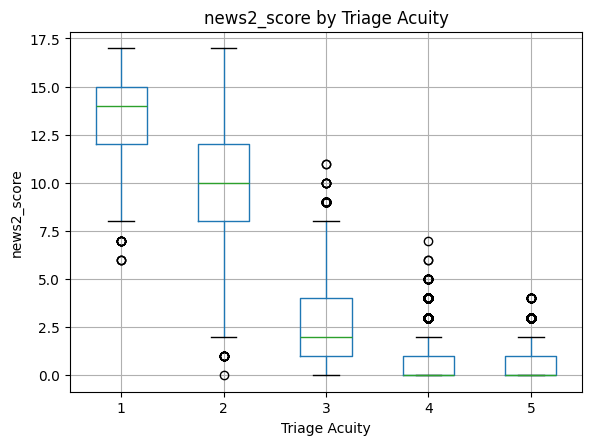

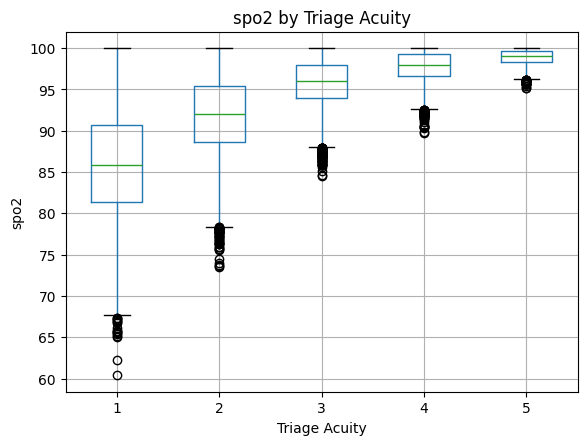

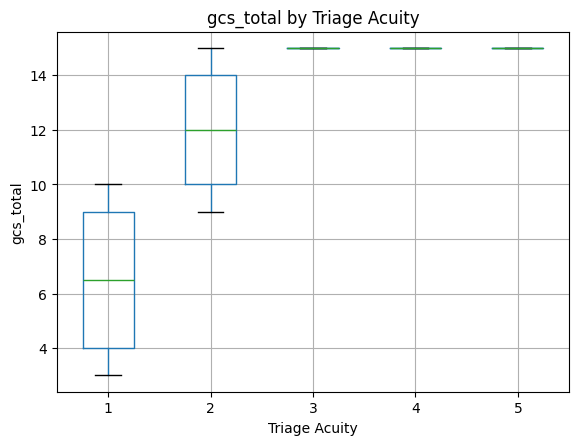

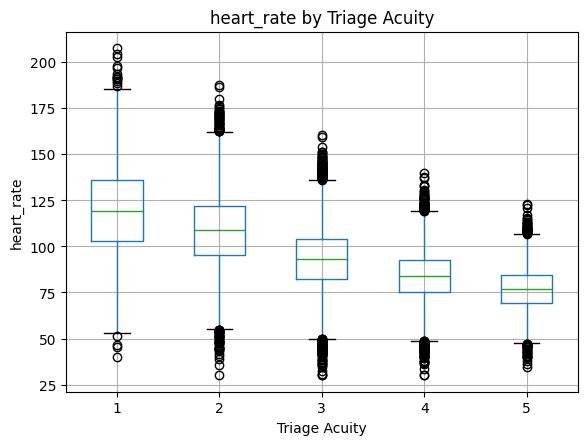

In [6]:
# -------------------------
# Cell 4: Clinical signal EDA
# -------------------------

key_num_cols = [
    "age",
    "systolic_bp", "diastolic_bp",
    "mean_arterial_pressure", "pulse_pressure",
    "heart_rate", "respiratory_rate",
    "temperature_c", "spo2", "gcs_total",
    "pain_score", "weight_kg", "height_cm", "bmi",
    "shock_index", "news2_score",
    "num_prior_ed_visits_12m", "num_prior_admissions_12m",
    "num_active_medications", "num_comorbidities"
]
key_num_cols = [c for c in key_num_cols if c in eda_df.columns]

print("Mean by triage_acuity:")
display(eda_df.groupby("triage_acuity")[key_num_cols].mean().round(2))

print("\nMedian by triage_acuity:")
display(eda_df.groupby("triage_acuity")[key_num_cols].median().round(2))

plot_cols = [c for c in ["news2_score", "spo2", "gcs_total", "heart_rate"] if c in eda_df.columns]

for col in plot_cols:
    eda_df.boxplot(column=col, by="triage_acuity")
    plt.title(f"{col} by Triage Acuity")
    plt.suptitle("")
    plt.xlabel("Triage Acuity")
    plt.ylabel(col)
    plt.show()

## Contextual, Textual, and History-Based Patterns

We explore subgroup patterns across arrival context, chief complaint categories, free-text complaint characteristics, and comorbidity history to identify where high-risk presentations may concentrate.

Most broad contextual variables, such as arrival mode, sex, age group, and season, show only modest differences in high-risk prevalence. In contrast, mental status at triage is strongly associated with severity, with `alert` patients showing a much lower high-risk rate than `drowsy` or `unresponsive` patients. Chief complaint categories show some variation, but the differences are smaller than those seen in physiological variables. In addition, higher-acuity patients tend to have longer chief complaint text and a greater burden of comorbidities, suggesting that text and history may provide useful secondary context beyond structured vital signs.

In [7]:
# -------------------------
# Cell 5: Context + text + history
# -------------------------

# 1) Categorical distribution vs acuity
cat_check_cols = [
    "arrival_mode", "sex", "shift", "arrival_day",
    "arrival_season", "mental_status_triage",
    "chief_complaint_system", "pain_location"
]
cat_check_cols = [c for c in cat_check_cols if c in eda_df.columns]

for col in cat_check_cols:
    print(f"\n[{col}] row-normalized crosstab")
    tab = pd.crosstab(eda_df[col], eda_df["triage_acuity"], normalize="index").round(3)
    display(tab.head(20))

# 2) High-risk ratio by subgroup
group_cols = [
    "arrival_mode", "sex", "age_group", "shift",
    "arrival_season", "mental_status_triage",
    "chief_complaint_system", "pain_location"
]
group_cols = [c for c in group_cols if c in eda_df.columns]

for col in group_cols:
    print(f"\n[{col}] high-risk ratio")
    grp = (
        eda_df.groupby(col)["high_risk"]
        .agg(["mean", "count"])
        .sort_values(["mean", "count"], ascending=[False, False])
        .round(4)
    )
    display(grp.head(15))

# 3) Text EDA
if "chief_complaint_raw" in eda_df.columns:
    eda_df["chief_len"] = eda_df["chief_complaint_raw"].fillna("").str.len()
    eda_df["chief_word_count"] = eda_df["chief_complaint_raw"].fillna("").str.split().str.len()

    print("\nChief complaint length summary:")
    display(eda_df[["chief_len", "chief_word_count"]].describe().round(2))

    print("\nChief complaint length by triage_acuity:")
    display(eda_df.groupby("triage_acuity")[["chief_len", "chief_word_count"]].mean().round(2))

# 4) Comorbidity EDA
hx_cols = [c for c in eda_df.columns if c.startswith("hx_")]

if len(hx_cols) > 0:
    hx_highrisk = eda_df.groupby("high_risk")[hx_cols].mean().T
    hx_highrisk.columns = ["not_high_risk", "high_risk"]
    hx_highrisk["diff_high_minus_low"] = hx_highrisk["high_risk"] - hx_highrisk["not_high_risk"]
    hx_highrisk = hx_highrisk.sort_values("diff_high_minus_low", ascending=False)

    print("\nTop comorbidities more common in high-risk patients:")
    display(hx_highrisk.head(15).round(4))

# 5) Quick takeaway table
summary_rows = [
    {"item": "train_rows", "value": eda_df.shape[0]},
    {"item": "n_features_after_merge", "value": eda_df.shape[1]},
    {"item": "high_risk_ratio_acuity_le_2", "value": round(eda_df["high_risk"].mean(), 4)},
]

if "pain_score" in eda_df.columns:
    summary_rows.append({
        "item": "pain_score_minus1_ratio",
        "value": round((eda_df["pain_score"] == -1).mean(), 4)
    })

if "news2_score" in eda_df.columns:
    summary_rows.append({
        "item": "mean_news2_acuity1",
        "value": round(eda_df.loc[eda_df["triage_acuity"] == 1, "news2_score"].mean(), 2)
    })
    summary_rows.append({
        "item": "mean_news2_acuity5",
        "value": round(eda_df.loc[eda_df["triage_acuity"] == 5, "news2_score"].mean(), 2)
    })

if "spo2" in eda_df.columns:
    summary_rows.append({
        "item": "mean_spo2_acuity1",
        "value": round(eda_df.loc[eda_df["triage_acuity"] == 1, "spo2"].mean(), 2)
    })
    summary_rows.append({
        "item": "mean_spo2_acuity5",
        "value": round(eda_df.loc[eda_df["triage_acuity"] == 5, "spo2"].mean(), 2)
    })

print("\nEDA Summary:")
display(pd.DataFrame(summary_rows))


[arrival_mode] row-normalized crosstab


triage_acuity,1,2,3,4,5
arrival_mode,,,,,
ambulance,0.041,0.167,0.360,0.289,0.143
brought_by_family,0.043,0.169,0.359,0.283,0.146
helicopter,0.047,0.153,0.375,0.283,0.141
police,0.039,0.171,0.359,0.282,0.149
transfer,0.039,0.162,0.364,0.291,0.144
walk-in,0.040,0.170,0.362,0.288,0.141



[sex] row-normalized crosstab


triage_acuity,1,2,3,4,5
sex,,,,,
F,0.040,0.169,0.361,0.287,0.143
M,0.040,0.167,0.362,0.288,0.142
Other,0.043,0.162,0.357,0.295,0.143



[shift] row-normalized crosstab


...

,chief_len,chief_word_count
triage_acuity,,
1,45.33,5.88
2,42.98,5.68
3,41.54,5.55
4,36.27,5.09
5,36.29,5.06



Top comorbidities more common in high-risk patients:


,not_high_risk,high_risk,diff_high_minus_low
hx_anxiety,0.1847,0.2517,0.0670
hx_liver_disease,0.1854,0.2518,0.0665
hx_asthma,0.1826,0.2490,0.0664
hx_diabetes_type1,0.1779,0.2432,0.0653
hx_hiv,0.1820,0.2472,0.0651
hx_hyperthyroidism,0.1858,0.2508,0.0650
hx_hypertension,0.2683,0.3325,0.0642
hx_immunosuppressed,0.1875,0.2512,0.0637
hx_coagulopathy,0.1847,0.2484,0.0636
hx_heart_failure,0.2679,0.3305,0.0626



EDA Summary:


,item,value
0,train_rows,80000.0000
1,n_features_after_merge,75.0000
2,high_risk_ratio_acuity_le_2,0.2083
3,pain_score_minus1_ratio,0.1394
4,mean_news2_acuity1,13.6400
5,mean_news2_acuity5,0.3500
6,mean_spo2_acuity1,85.8600
7,mean_spo2_acuity5,98.9200


## EDA Summary

This exploratory analysis supports the core project hypothesis. First, the dataset shows clinically plausible severity gradients: higher-acuity patients consistently present with lower blood pressure, lower SpO2, lower GCS, and higher heart rate, respiratory rate, temperature, and NEWS2 score. Second, even among patients recorded as `alert` at triage, a small but important subgroup still falls into the high-risk category (`triage_acuity <= 2`). Finally, broad contextual variables alone provide limited separation, while physiological signals appear to carry most of the discriminative information. Taken together, these findings motivate a simple and interpretable physiology-based baseline model for identifying hidden high-risk patients among apparently stable triage presentations.

## Alert Subgroup for Modeling

To focus on hidden high-risk cases among apparently stable presentations, the downstream modeling task is restricted to patients recorded as `alert` at triage. Within this subgroup, we define high-risk cases as patients with `triage_acuity <= 2`.

In [8]:
alert_df = train_df[train_df["mental_status_triage"] == "alert"].copy()
alert_df["high_risk"] = (alert_df["triage_acuity"] <= 2).astype(int)

print("alert_df shape:", alert_df.shape)
print("alert high-risk ratio:", alert_df["high_risk"].mean().round(4))
print(alert_df["high_risk"].value_counts())

alert_df shape: (46212, 67)
alert high-risk ratio: 0.0304
high_risk
0    44805
1     1407
Name: count, dtype: int64


## Leakage Audit and Validity Checks

Before interpreting model performance, we examined whether the dataset contained train-test overlap, duplicated patient records, or direct post-outcome leakage.

The audit suggests that there is no obvious train-test leakage: patient IDs are unique within both `train_df` and `test_df`, there is no overlap between the two tables, and the train/validation split within the alert subgroup is also clean. In addition, direct leakage columns such as `triage_acuity`, `high_risk`, `disposition`, `ed_los_hours`, patient identifiers, and raw complaint text were excluded from the modeling feature set.

However, the audit also shows that some variables remain highly target-proximal. In particular, `news2_score`, `shock_index`, `mean_arterial_pressure`, and `pulse_pressure` are closely related to physiological severity and may make the task easier. We also observe structured missingness: missing blood pressure, respiratory rate, and temperature measurements occur almost exclusively in lower-risk patients, suggesting that missingness may encode triage workflow patterns rather than pure noise.

Taken together, these checks suggest that the baseline results are not driven by obvious leakage, but may still be inflated by clinically strong summary variables and workflow-related missingness patterns.

In [9]:
# =========================================
# LEAKAGE / SPLIT AUDIT
# =========================================

print("=" * 80)
print("1) BASIC UNIQUENESS CHECKS")
print("=" * 80)

print("train_df rows:", len(train_df))
print("unique patient_id in train_df:", train_df["patient_id"].nunique())
print("test_df rows:", len(test_df))
print("unique patient_id in test_df:", test_df["patient_id"].nunique())

print("\nAny duplicated patient_id in train_df?",
      train_df["patient_id"].duplicated().any())
print("Any duplicated patient_id in test_df?",
      test_df["patient_id"].duplicated().any())

print("\nTrain/Test patient_id overlap:",
      len(set(train_df["patient_id"]).intersection(set(test_df["patient_id"]))))

print("\n" + "=" * 80)
print("2) ALERT SUBSET SPLIT AUDIT")
print("=" * 80)

audit_df = train_df.copy()
alert_df = audit_df[audit_df["mental_status_triage"] == "alert"].copy()
alert_df["high_risk"] = (alert_df["triage_acuity"] <= 2).astype(int)

drop_cols = [
    "patient_id",
    "triage_nurse_id",
    "site_id",
    "triage_acuity",
    "high_risk",
    "disposition",
    "ed_los_hours",
    "chief_complaint_raw",
]

feature_cols = [c for c in alert_df.columns if c not in drop_cols]
X = alert_df[feature_cols].copy()
y = alert_df["high_risk"].copy()

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

train_idx = set(X_train.index)
valid_idx = set(X_valid.index)

print("Train/Valid index overlap:", len(train_idx.intersection(valid_idx)))

train_patients = set(alert_df.loc[X_train.index, "patient_id"])
valid_patients = set(alert_df.loc[X_valid.index, "patient_id"])
print("Train/Valid patient_id overlap:", len(train_patients.intersection(valid_patients)))

print("\n" + "=" * 80)
print("3) FEATURE LEAKAGE CHECK")
print("=" * 80)

feature_cols_now = X.columns.tolist()
suspicious_cols = [
    "triage_acuity",
    "high_risk",
    "disposition",
    "ed_los_hours",
    "patient_id",
    "triage_nurse_id",
    "chief_complaint_raw",
]

for col in suspicious_cols:
    print(f"{col} in features? ->", col in feature_cols_now)

print("\nCurrent feature count:", len(feature_cols_now))
print("Current features:")
print(feature_cols_now)

print("\n" + "=" * 80)
print("4) EXACT DUPLICATE FEATURE ROWS CHECK")
print("=" * 80)

dup_count = X.duplicated().sum()
print("Exact duplicate feature rows in alert_df:", dup_count)

tmp = X.copy()
tmp["high_risk"] = y.values
conflict_check = tmp.groupby(list(X.columns))["high_risk"].nunique().reset_index(name="n_unique_labels")
conflict_rows = conflict_check[conflict_check["n_unique_labels"] > 1]
print("Exact duplicate feature rows with conflicting labels:", len(conflict_rows))

print("\n" + "=" * 80)
print("5) TARGET PROXIMITY CHECK (not true leakage, but too-close features)")
print("=" * 80)

proxy_cols = [
    "news2_score",
    "shock_index",
    "mean_arterial_pressure",
    "pulse_pressure",
    "mental_status_triage"
]

for col in proxy_cols:
    print(f"{col} present? ->", col in alert_df.columns)

print("\nHigh-risk rate by selected proxy-like features:")
for col in ["news2_score", "shock_index", "systolic_bp", "spo2", "gcs_total"]:
    if col in alert_df.columns:
        print(f"\n{col}")
        print(alert_df.groupby("high_risk")[col].mean().round(3))

print("\n" + "=" * 80)
print("6) MISSINGNESS SHORTCUT CHECK")
print("=" * 80)

for col in ["systolic_bp", "diastolic_bp", "respiratory_rate", "temperature_c"]:
    if col in alert_df.columns:
        miss = alert_df[col].isna().astype(int)
        print(f"\n{col}_missing vs high_risk")
        print(pd.crosstab(miss, alert_df["high_risk"], normalize="index").round(4))

print("\n" + "=" * 80)
print("7) TRAIN-ONLY / FUTURE-ONLY COLUMN REVIEW")
print("=" * 80)

future_or_post_event_cols = ["disposition", "ed_los_hours"]
for col in future_or_post_event_cols:
    if col in train_df.columns:
        print(f"{col}: PRESENT in train_df, but should NOT be used as feature")
    else:
        print(f"{col}: not found")

print("\nAudit complete.")

1) BASIC UNIQUENESS CHECKS
train_df rows: 80000
unique patient_id in train_df: 80000
test_df rows: 20000
unique patient_id in test_df: 20000

Any duplicated patient_id in train_df? False
Any duplicated patient_id in test_df? False

Train/Test patient_id overlap: 0

2) ALERT SUBSET SPLIT AUDIT
Train/Valid index overlap: 0
Train/Valid patient_id overlap: 0

3) FEATURE LEAKAGE CHECK
triage_acuity in features? -> False
high_risk in features? -> False
disposition in features? -> False
ed_los_hours in features? -> False
patient_id in features? -> False
triage_nurse_id in features? -> False
chief_complaint_raw in features? -> False

Current feature count: 59
Current features:
['arrival_mode', 'arrival_hour', 'arrival_day', 'arrival_month', 'arrival_season', 'shift', 'age', 'age_group', 'sex', 'language', 'insurance_type', 'transport_origin', 'pain_location', 'mental_status_triage', 'num_prior_ed_visits_12m', 'num_prior_admissions_12m', 'num_active_medications', 'num_comorbidities', 'systolic_

## Baseline and Strict Baseline Modeling

We next compare two logistic regression models on the alert subgroup. The primary baseline uses a broad structured feature set, while the strict baseline uses only a minimal set of raw demographic/context features and basic vital signs.

To make the comparison fair, both models are evaluated with the same train/validation split, the same preprocessing pipeline, and the same reporting scheme.

In [10]:
def run_logit_experiment(
    df,
    feature_cols,
    target_col="high_risk",
    model_name="model",
    thresholds=[0.50, 0.30, 0.20, 0.10],
    topk_pcts=[0.01, 0.03, 0.05, 0.10],
):
    X = df[feature_cols].copy()
    y = df[target_col].copy()

    # pain_score handling
    if "pain_score" in X.columns:
        X["pain_score"] = X["pain_score"].replace(-1, np.nan)

    cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
    num_cols = [c for c in X.columns if c not in cat_cols]

    X_train, X_valid, y_train, y_valid = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    numeric_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer([
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ])

    model = Pipeline([
        ("prep", preprocessor),
        ("clf", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        ))
    ])

    model.fit(X_train, y_train)
    pred_proba = model.predict_proba(X_valid)[:, 1]

    # summary metrics
    roc_auc = roc_auc_score(y_valid, pred_proba)
    pr_auc = average_precision_score(y_valid, pred_proba)

    # threshold results
    threshold_results = {}
    for th in thresholds:
        pred = (pred_proba >= th).astype(int)
        threshold_results[th] = {
            "confusion_matrix": confusion_matrix(y_valid, pred),
            "classification_report": classification_report(y_valid, pred, digits=4, output_dict=True)
        }

    # top-k results
    valid_eval = pd.DataFrame({
        "y_true": y_valid.values,
        "risk_score": pred_proba
    }).sort_values("risk_score", ascending=False).reset_index(drop=True)

    total_high_risk = valid_eval["y_true"].sum()
    topk_rows = []

    for pct in topk_pcts:
        k = int(len(valid_eval) * pct)
        topk = valid_eval.head(k)
        flagged_high_risk = int(topk["y_true"].sum())
        precision = topk["y_true"].mean()
        capture = flagged_high_risk / total_high_risk if total_high_risk > 0 else 0.0

        topk_rows.append({
            "model": model_name,
            "topk_pct": pct,
            "n_flagged": k,
            "high_risk_found": flagged_high_risk,
            "precision": precision,
            "capture_of_all_high_risk": capture
        })

    topk_df = pd.DataFrame(topk_rows)

    return {
        "model_name": model_name,
        "feature_count": len(feature_cols),
        "cat_count": len(cat_cols),
        "num_count": len(num_cols),
        "X_train_shape": X_train.shape,
        "X_valid_shape": X_valid.shape,
        "train_high_risk_ratio": y_train.mean(),
        "valid_high_risk_ratio": y_valid.mean(),
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "threshold_results": threshold_results,
        "topk_df": topk_df,
        "model": model,
        "pred_proba": pred_proba,
        "y_valid": y_valid,
        "feature_cols": feature_cols,
    }

In [11]:
def print_logit_results(result, thresholds=[0.50, 0.30, 0.20, 0.10]):
    print("=" * 80)
    print(f"{result['model_name'].upper()} RESULTS")
    print("=" * 80)

    print("Number of features before encoding:", result["feature_count"])
    print("categorical cols:", result["cat_count"])
    print("numeric cols:", result["num_count"])

    print("\nTrain shape:", result["X_train_shape"], "Valid shape:", result["X_valid_shape"])
    print("Train high_risk ratio:", round(result["train_high_risk_ratio"], 4))
    print("Valid high_risk ratio:", round(result["valid_high_risk_ratio"], 4))

    print("\nROC-AUC:", round(result["roc_auc"], 4))
    print("PR-AUC :", round(result["pr_auc"], 4))

    for th in thresholds:
        cm = result["threshold_results"][th]["confusion_matrix"]
        report = pd.DataFrame(result["threshold_results"][th]["classification_report"]).T

        print(f"\nConfusion Matrix @ {th:.2f} threshold")
        print(cm)

        print(f"\nClassification Report @ {th:.2f} threshold")
        display(report)

    print("\nTop-k capture analysis")
    display(result["topk_df"].copy())

### Primary Baseline Feature Set

The primary baseline uses the broad structured feature set after excluding identifiers, direct target variables, post-outcome variables, and raw free-text complaint strings. It also includes missingness indicators to reflect the original baseline setting.

In [12]:
baseline_features = [
    c for c in alert_df.columns
    if c not in [
        "patient_id",
        "triage_nurse_id",
        "site_id",
        "triage_acuity",
        "high_risk",
        "disposition",
        "ed_los_hours",
        "chief_complaint_raw",
    ]
]

# baseline only: missingness flags 추가
for col in ["pain_score", "systolic_bp", "diastolic_bp", "respiratory_rate", "temperature_c"]:
    if col == "pain_score":
        flag_col = "pain_score_missing_flag"
        if flag_col not in alert_df.columns:
            alert_df[flag_col] = (alert_df["pain_score"] == -1).astype(int)
    else:
        flag_col = f"{col}_missing_flag"
        if col in alert_df.columns and flag_col not in alert_df.columns:
            alert_df[flag_col] = alert_df[col].isna().astype(int)

for extra_col in [
    "pain_score_missing_flag",
    "systolic_bp_missing_flag",
    "diastolic_bp_missing_flag",
    "respiratory_rate_missing_flag",
    "temperature_c_missing_flag",
]:
    if extra_col in alert_df.columns and extra_col not in baseline_features:
        baseline_features.append(extra_col)

### Strict Baseline Feature Set

The strict baseline removes target-proximal summary variables and workflow shortcut features. It keeps only a small set of raw demographic/context variables and core vital signs in order to test whether the strong baseline performance persists under a more conservative feature design.

In [13]:
strict_features = [
    "age",
    "sex",
    "arrival_mode",
    "arrival_hour",
    "systolic_bp",
    "diastolic_bp",
    "heart_rate",
    "respiratory_rate",
    "temperature_c",
    "spo2",
    "gcs_total",
    "pain_score",
]

strict_features = [c for c in strict_features if c in alert_df.columns]

In [14]:
baseline_result = run_logit_experiment(
    alert_df,
    baseline_features,
    model_name="baseline"
)

strict_result = run_logit_experiment(
    alert_df,
    strict_features,
    model_name="strict baseline"
)

### Baseline Result Summary

The baseline logistic regression model performs extremely well on the alert subgroup. It achieves a ROC-AUC of 0.9993 and a PR-AUC of 0.9871, indicating that hidden high-risk patients can be separated from low-risk patients with very strong discrimination even using a simple interpretable model.

At the default threshold of 0.50, the model reaches a recall of 0.9822 for hidden high-risk cases, meaning that only a very small number of urgent patients are missed. Lowering the threshold further increases recall slightly, but at the cost of lower precision. This suggests that the model can be tuned depending on whether the clinical priority is to minimize missed urgent cases or to limit the number of unnecessary re-reviews.

The ranking-based operating view is especially informative. When alert patients are sorted by predicted risk, reviewing only the top 3% captures 93.95% of all hidden high-risk cases, while reviewing the top 5% captures 98.93%. This supports the idea that the model may be most useful as a secondary safety-net for prioritizing re-evaluation among patients who appear stable at triage, rather than as a replacement for clinician judgment.

In [15]:
print_logit_results(baseline_result)

BASELINE RESULTS
Number of features before encoding: 64
categorical cols: 12
numeric cols: 52

Train shape: (36969, 64) Valid shape: (9243, 64)
Train high_risk ratio: 0.0305
Valid high_risk ratio: 0.0304

ROC-AUC: 0.9993
PR-AUC : 0.9871

Confusion Matrix @ 0.50 threshold
[[8892   70]
 [   5  276]]

Classification Report @ 0.50 threshold


,precision,recall,f1-score,support
0,0.999438,0.992189,0.995800,8962.000000
1,0.797688,0.982206,0.880383,281.000000
accuracy,0.991886,0.991886,0.991886,0.991886
macro avg,0.898563,0.987198,0.938092,9243.000000
weighted avg,0.993305,0.991886,0.992292,9243.000000



Confusion Matrix @ 0.30 threshold
[[8866   96]
 [   4  277]]

Classification Report @ 0.30 threshold


,precision,recall,f1-score,support
0,0.999549,0.989288,0.994392,8962.000000
1,0.742627,0.985765,0.847095,281.000000
accuracy,0.989181,0.989181,0.989181,0.989181
macro avg,0.871088,0.987527,0.920743,9243.000000
weighted avg,0.991738,0.989181,0.989914,9243.000000



Confusion Matrix @ 0.20 threshold
[[8833  129]
 [   3  278]]

Classification Report @ 0.20 threshold


,precision,recall,f1-score,support
0,0.999660,0.985606,0.992583,8962.000000
1,0.683047,0.989324,0.808140,281.000000
accuracy,0.985719,0.985719,0.985719,0.985719
macro avg,0.841354,0.987465,0.900361,9243.000000
weighted avg,0.990035,0.985719,0.986976,9243.000000



Confusion Matrix @ 0.10 threshold
[[8786  176]
 [   3  278]]

Classification Report @ 0.10 threshold


,precision,recall,f1-score,support
0,0.999659,0.980362,0.989916,8962.000000
1,0.612335,0.989324,0.756463,281.000000
accuracy,0.980634,0.980634,0.980634,0.980634
macro avg,0.805997,0.984843,0.873189,9243.000000
weighted avg,0.987883,0.980634,0.982819,9243.000000



Top-k capture analysis


,model,topk_pct,n_flagged,high_risk_found,precision,capture_of_all_high_risk
0,baseline,0.01,92,92,1.000000,0.327402
1,baseline,0.03,277,264,0.953069,0.939502
2,baseline,0.05,462,278,0.601732,0.989324
3,baseline,0.10,924,281,0.304113,1.000000


### Strict Baseline Result Summary

The strict baseline remains extremely strong even after restricting the feature set to a small group of raw demographic/context variables and basic vital signs. It achieves a ROC-AUC of 0.9985 and a PR-AUC of 0.9855, showing that most of the predictive signal is already present in simple physiological measurements rather than depending only on derived summary scores or missingness shortcuts.

At the default threshold of 0.50, the strict model still reaches a recall of 0.9822 for hidden high-risk cases, with only a modest drop in precision relative to the broader baseline. This indicates that the core separation between hidden high-risk and low-risk patients is largely preserved even under a more conservative feature design.

The ranking-based operating view remains especially strong. Reviewing only the top 3% of alert patients captures 95.02% of all hidden high-risk cases, while reviewing the top 5% captures 98.93%. Taken together, these results suggest that the strong baseline performance is not driven only by target-proximal summary variables. Instead, much of the signal appears to come directly from basic physiological features themselves.

In [16]:
print_logit_results(strict_result)

STRICT BASELINE RESULTS
Number of features before encoding: 12
categorical cols: 2
numeric cols: 10

Train shape: (36969, 12) Valid shape: (9243, 12)
Train high_risk ratio: 0.0305
Valid high_risk ratio: 0.0304

ROC-AUC: 0.9985
PR-AUC : 0.9855

Confusion Matrix @ 0.50 threshold
[[8862  100]
 [   5  276]]

Classification Report @ 0.50 threshold


,precision,recall,f1-score,support
0,0.999436,0.988842,0.994111,8962.00000
1,0.734043,0.982206,0.840183,281.00000
accuracy,0.988640,0.988640,0.988640,0.98864
macro avg,0.866739,0.985524,0.917147,9243.00000
weighted avg,0.991368,0.988640,0.989431,9243.00000



Confusion Matrix @ 0.30 threshold
[[8771  191]
 [   3  278]]

Classification Report @ 0.30 threshold


,precision,recall,f1-score,support
0,0.999658,0.978688,0.989062,8962.000000
1,0.592751,0.989324,0.741333,281.000000
accuracy,0.979011,0.979011,0.979011,0.979011
macro avg,0.796204,0.984006,0.865198,9243.000000
weighted avg,0.987288,0.979011,0.981531,9243.000000



Confusion Matrix @ 0.20 threshold
[[8679  283]
 [   3  278]]

Classification Report @ 0.20 threshold


,precision,recall,f1-score,support
0,0.999654,0.968422,0.983791,8962.000000
1,0.495544,0.989324,0.660333,281.000000
accuracy,0.969058,0.969058,0.969058,0.969058
macro avg,0.747599,0.978873,0.822062,9243.000000
weighted avg,0.984329,0.969058,0.973957,9243.000000



Confusion Matrix @ 0.10 threshold
[[8493  469]
 [   2  279]]

Classification Report @ 0.10 threshold


,precision,recall,f1-score,support
0,0.999765,0.947668,0.973019,8962.000000
1,0.372995,0.992883,0.542274,281.000000
accuracy,0.949043,0.949043,0.949043,0.949043
macro avg,0.686380,0.970275,0.757647,9243.000000
weighted avg,0.980710,0.949043,0.959924,9243.000000



Top-k capture analysis


,model,topk_pct,n_flagged,high_risk_found,precision,capture_of_all_high_risk
0,strict baseline,0.01,92,92,1.000000,0.327402
1,strict baseline,0.03,277,267,0.963899,0.950178
2,strict baseline,0.05,462,278,0.601732,0.989324
3,strict baseline,0.10,924,279,0.301948,0.992883


### Baseline vs Strict Baseline Comparison

The performance gap between the two models is very small. Although the strict baseline reduces the feature set from 64 variables to only 12, its ROC-AUC decreases only from 0.9993 to 0.9985 and its PR-AUC from 0.9871 to 0.9855. This suggests that the strong predictive performance is not driven only by a broad set of engineered or target-proximal variables. Instead, most of the discriminative signal appears to be captured directly by a small set of basic physiological and intake features.

In [17]:
compare_df = pd.DataFrame([
    {
        "model": baseline_result["model_name"],
        "feature_count": baseline_result["feature_count"],
        "roc_auc": baseline_result["roc_auc"],
        "pr_auc": baseline_result["pr_auc"],
    },
    {
        "model": strict_result["model_name"],
        "feature_count": strict_result["feature_count"],
        "roc_auc": strict_result["roc_auc"],
        "pr_auc": strict_result["pr_auc"],
    }
]).round(4)

compare_df

,model,feature_count,roc_auc,pr_auc
0,baseline,64,0.9993,0.9871
1,strict baseline,12,0.9985,0.9855


## Final Result Summary

This study examined whether hidden high-risk patients can be identified among emergency department arrivals who appear stable at triage, especially those recorded as `alert`. The exploratory analysis showed that a small but clinically important subset of alert patients still belonged to the high-risk group (`triage_acuity <= 2`), confirming that apparent stability does not necessarily imply safety.

A baseline logistic regression model achieved extremely strong performance on this subgroup, and a much stricter version using only 12 raw demographic/context and vital-sign features performed almost as well. Because the strict baseline remained highly competitive, the results suggest that most of the predictive signal does not come only from broad engineered features or summary scores, but is already strongly present in basic physiological measurements observed at triage.

From an operational perspective, the model is most useful as a secondary safety-net rather than a replacement for clinician judgment. When alert patients are ranked by predicted risk, reviewing only a small fraction of cases is sufficient to recover most hidden high-risk patients. Overall, these findings suggest that apparently stable triage presentations may still contain recoverable urgent cases, and that a simple interpretable physiology-based model can help prioritize re-evaluation more effectively.

## Model Interpretation and Operating Scenario

To understand how the strict baseline works in practice, we examine three aspects: which features drive predictions most strongly, which urgent cases are still missed, and how the model could be used as a re-review ranking tool in a realistic workflow.

The following results are discussed in more detail directly below each corresponding code output.

In [18]:
# =========================================
# INTERPRETATION ONLY: STRICT BASELINE
# =========================================

# Rebuild the same strict design matrix so we can align metadata with validation rows
X_strict = alert_df[strict_features].copy()
y_strict = alert_df["high_risk"].copy()

if "pain_score" in X_strict.columns:
    X_strict["pain_score"] = X_strict["pain_score"].replace(-1, np.nan)

# Use the same split setting as the strict baseline
X_train_s, X_valid_s, y_train_s, y_valid_s = train_test_split(
    X_strict,
    y_strict,
    test_size=0.2,
    random_state=42,
    stratify=y_strict
)

valid_meta = alert_df.loc[X_valid_s.index].copy()

# Pull already-trained strict model outputs
strict_model = strict_result["model"]
valid_pred_proba = strict_result["pred_proba"]
y_valid = strict_result["y_valid"]

# Sanity check
print("Validation rows from split:", len(X_valid_s))
print("Prediction rows from strict_result:", len(valid_pred_proba))

# -------------------------------------------------
# 1) Coefficients / importance
# -------------------------------------------------
print("\n" + "=" * 80)
print("COEFFICIENT / IMPORTANCE")
print("=" * 80)

fitted_preprocessor = strict_model.named_steps["prep"]
fitted_clf = strict_model.named_steps["clf"]

feature_names = fitted_preprocessor.get_feature_names_out()
coefs = fitted_clf.coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefs,
    "abs_coefficient": np.abs(coefs)
}).sort_values("abs_coefficient", ascending=False)

print("\nTop 20 features by absolute coefficient:")
display(coef_df.head(20))

print("\nTop 15 features increasing high-risk probability:")
display(coef_df.sort_values("coefficient", ascending=False).head(15))

print("\nTop 15 features decreasing high-risk probability:")
display(coef_df.sort_values("coefficient", ascending=True).head(15))

# -------------------------------------------------
# 2) False negative analysis
# -------------------------------------------------
print("\n" + "=" * 80)
print("FALSE NEGATIVE ANALYSIS")
print("=" * 80)

valid_result = valid_meta.copy()
valid_result["y_true"] = y_valid.values
valid_result["risk_score"] = valid_pred_proba
valid_result["pred_050"] = (valid_pred_proba >= 0.50).astype(int)

false_negatives = valid_result[(valid_result["y_true"] == 1) & (valid_result["pred_050"] == 0)].copy()
false_positives = valid_result[(valid_result["y_true"] == 0) & (valid_result["pred_050"] == 1)].copy()
true_positives = valid_result[(valid_result["y_true"] == 1) & (valid_result["pred_050"] == 1)].copy()

print("False negatives @ 0.50:", len(false_negatives))
print("False positives @ 0.50:", len(false_positives))
print("True positives @ 0.50:", len(true_positives))

key_review_cols = [
    "patient_id",
    "triage_acuity",
    "risk_score",
    "age",
    "sex",
    "arrival_mode",
    "arrival_hour",
    "systolic_bp",
    "diastolic_bp",
    "heart_rate",
    "respiratory_rate",
    "temperature_c",
    "spo2",
    "gcs_total",
    "pain_score",
    "chief_complaint_raw",
    "chief_complaint_system",
]
key_review_cols = [c for c in key_review_cols if c in false_negatives.columns]

print("\nFalse negative sample rows:")
display(false_negatives[key_review_cols].sort_values("risk_score", ascending=True).head(20))

compare_cols = [c for c in [
    "age",
    "systolic_bp", "diastolic_bp",
    "heart_rate", "respiratory_rate", "temperature_c",
    "spo2", "gcs_total", "pain_score"
] if c in valid_result.columns]

fn_summary = pd.DataFrame({
    "false_negative_mean": false_negatives[compare_cols].mean(),
    "true_positive_mean": true_positives[compare_cols].mean(),
    "all_high_risk_mean": valid_result.loc[valid_result["y_true"] == 1, compare_cols].mean(),
}).round(3)

print("\nFalse negatives vs true positives summary:")
display(fn_summary)

for col in ["arrival_mode", "sex", "chief_complaint_system"]:
    if col in valid_result.columns:
        print(f"\nFalse negatives by {col}:")
        display(false_negatives[col].value_counts(dropna=False).to_frame("count").head(15))

# -------------------------------------------------
# 3) Operating scenario: top-k review
# -------------------------------------------------
print("\n" + "=" * 80)
print("TOP-K RE-REVIEW OPERATING SCENARIO")
print("=" * 80)

valid_ranked = valid_result[["patient_id", "y_true", "risk_score"]].copy()
valid_ranked = valid_ranked.sort_values("risk_score", ascending=False).reset_index(drop=True)

total_high_risk = valid_ranked["y_true"].sum()

scenario_rows = []
for pct in [0.01, 0.03, 0.05, 0.10]:
    k = int(len(valid_ranked) * pct)
    topk = valid_ranked.head(k)
    flagged_high_risk = int(topk["y_true"].sum())
    precision = topk["y_true"].mean()
    capture = flagged_high_risk / total_high_risk if total_high_risk > 0 else 0.0

    scenario_rows.append({
        "review_share": f"Top {int(pct*100)}%",
        "n_flagged": k,
        "high_risk_found": flagged_high_risk,
        "precision_among_flagged": round(precision, 4),
        "capture_of_all_high_risk": round(capture, 4),
    })

scenario_df = pd.DataFrame(scenario_rows)
display(scenario_df)

print("\nThreshold-based scenario summary:")
threshold_rows = []
for th in [0.50, 0.30, 0.20, 0.10]:
    pred_th = (valid_pred_proba >= th).astype(int)
    n_flagged = int(pred_th.sum())
    tp = int(((pred_th == 1) & (y_valid.values == 1)).sum())
    precision = tp / n_flagged if n_flagged > 0 else 0.0
    recall = tp / total_high_risk if total_high_risk > 0 else 0.0

    threshold_rows.append({
        "threshold": th,
        "n_flagged": n_flagged,
        "high_risk_found": tp,
        "precision": round(precision, 4),
        "recall_capture": round(recall, 4),
    })

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df)

Validation rows from split: 9243
Prediction rows from strict_result: 9243

COEFFICIENT / IMPORTANCE

Top 20 features by absolute coefficient:


,feature,coefficient,abs_coefficient
8,num__gcs_total,-5.774403,5.774403
12,cat__sex_Other,-2.111383,2.111383
14,cat__arrival_mode_brought_by_family,-1.896058,1.896058
11,cat__sex_M,-1.442379,1.442379
6,num__temperature_c,1.342997,1.342997
2,num__systolic_bp,-1.316253,1.316253
9,num__pain_score,1.257707,1.257707
5,num__respiratory_rate,1.235833,1.235833
16,cat__arrival_mode_police,-1.051261,1.051261
10,cat__sex_F,-1.008957,1.008957



Top 15 features increasing high-risk probability:


,feature,coefficient,abs_coefficient
6,num__temperature_c,1.342997,1.342997
9,num__pain_score,1.257707,1.257707
5,num__respiratory_rate,1.235833,1.235833
4,num__heart_rate,0.349373,0.349373
0,num__age,0.082133,0.082133
1,num__arrival_hour,-0.049903,0.049903
15,cat__arrival_mode_helicopter,-0.172413,0.172413
13,cat__arrival_mode_ambulance,-0.412071,0.412071
18,cat__arrival_mode_walk-in,-0.466618,0.466618
17,cat__arrival_mode_transfer,-0.564299,0.564299



Top 15 features decreasing high-risk probability:


...

,count
chief_complaint_system,
dermatological,2
cardiovascular,1
neurological,1
musculoskeletal,1



TOP-K RE-REVIEW OPERATING SCENARIO


,review_share,n_flagged,high_risk_found,precision_among_flagged,capture_of_all_high_risk
0,Top 1%,92,92,1.0000,0.3274
1,Top 3%,277,267,0.9639,0.9502
2,Top 5%,462,278,0.6017,0.9893
3,Top 10%,924,279,0.3019,0.9929



Threshold-based scenario summary:


,threshold,n_flagged,high_risk_found,precision,recall_capture
0,0.5,376,276,0.7340,0.9822
1,0.3,469,278,0.5928,0.9893
2,0.2,561,278,0.4955,0.9893
3,0.1,748,279,0.3730,0.9929


### Coefficient Summary

The strict baseline is primarily driven by core physiological variables. Among all features, `gcs_total` shows the strongest negative association with hidden high-risk status, while higher `temperature_c`, `pain_score`, and `respiratory_rate` are among the strongest positive contributors. Lower blood pressure (`systolic_bp`, `diastolic_bp`) and lower `spo2` also increase predicted risk. Overall, these coefficients suggest that the model is relying on clinically interpretable instability signals rather than complex engineered features.

Categorical coefficients should be interpreted more cautiously because they are relative to a reference category after one-hot encoding. In contrast, the direction of the core continuous vital-sign coefficients is more directly meaningful and aligns well with the earlier EDA.

### False Negative Review

At the default threshold of 0.50, the strict baseline misses only 5 hidden high-risk cases. These false negatives appear to be clinically subtler than the correctly flagged urgent cases: compared with true positives, they have fully normal `gcs_total` values, somewhat better oxygen saturation, and less extreme heart rate, respiratory rate, and temperature patterns. This suggests that the remaining missed cases are not obvious physiological outliers, but rather borderline or atypical urgent presentations.

The false negative examples also span multiple complaint categories, including dermatological, musculoskeletal, cardiovascular, and neurological presentations. This pattern suggests that some urgent cases may remain difficult to detect when their physiological abnormalities are less pronounced or when the strict feature set does not fully capture the clinical nuance of the presenting complaint.

### Operating Scenario: Risk-Based Re-Review

The ranking-based operating scenario is especially promising. When alert patients are sorted by predicted risk, reviewing only the top 3% captures 95.02% of all hidden high-risk cases, while reviewing the top 5% captures 98.93%. This means that a relatively small secondary review pool could recover most urgent cases that initially appear stable at triage.

This framing is clinically important because the model is not intended to replace clinician judgment. Instead, it can function as a secondary safety-net that prioritizes which apparently stable patients should receive additional review. In practice, this may be more realistic and more useful than treating the model as a hard yes/no triage decision rule.

### Threshold-Based Trade-Off

At the default threshold of 0.50, the model flags 376 patients and correctly identifies 276 hidden high-risk cases, corresponding to a precision of 0.7340 and a recall capture of 0.9822. Lowering the threshold slightly increases recall further, but also increases the number of flagged patients and reduces precision. This illustrates the expected operational trade-off between minimizing missed urgent cases and controlling the review workload.

For deployment, the threshold should therefore be chosen based on workflow priorities. If the main goal is to reduce missed urgent cases as much as possible, a lower threshold may be appropriate. If the goal is to keep the review burden smaller, a more selective threshold or a top-k ranking approach may be preferable.

# APPENDIX

## Appendix A. Ablation Ladder

To test whether the strong performance depends mainly on target-proximal summaries or workflow shortcuts, I compare a sequence of increasingly strict feature sets using the same split and the same logistic regression pipeline.

APPENDIX A — ABLATION LADDER RESULTS


,model,feature_count,roc_auc,pr_auc,precision_at_050,recall_at_050,brier_score,top3_n_flagged,top3_found,top3_precision,top3_capture,top5_n_flagged,top5_found,top5_precision,top5_capture
0,A_broad_baseline,63,0.9993,0.9872,0.7925,0.9786,0.0062,277,263,0.9495,0.9359,462,278,0.6017,0.9893
1,B_minus_derived_scores,59,0.9990,0.9835,0.7884,0.9680,0.0068,277,264,0.9531,0.9395,462,277,0.5996,0.9858
2,C_minus_derived_and_missing_flags,54,0.9990,0.9832,0.7953,0.9680,0.0070,277,264,0.9531,0.9395,462,277,0.5996,0.9858
3,D_strict_baseline,12,0.9985,0.9855,0.7340,0.9822,0.0089,277,267,0.9639,0.9502,462,278,0.6017,0.9893
4,E_ultra_strict_vitals_plus_age,9,0.9989,0.9864,0.7289,0.9858,0.0089,277,267,0.9639,0.9502,462,278,0.6017,0.9893


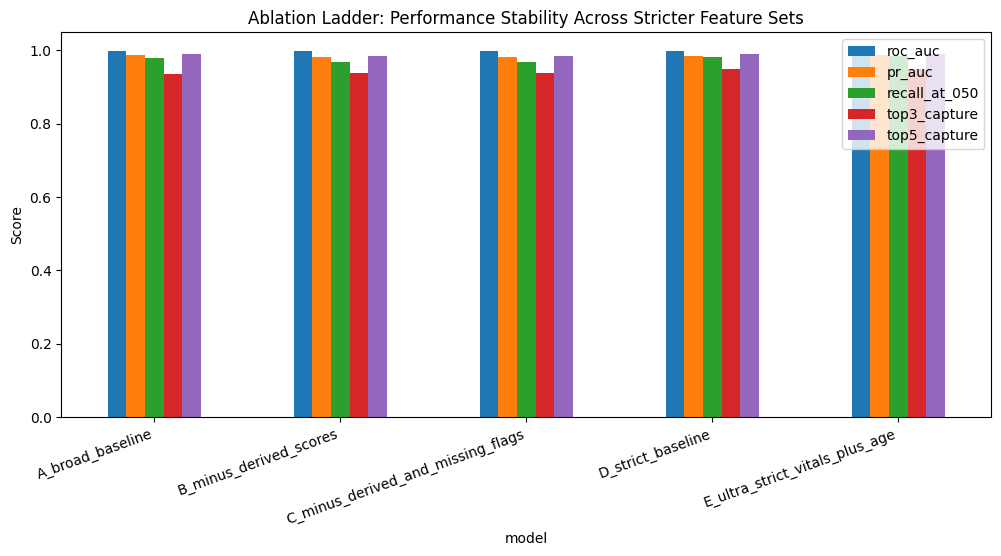

In [19]:
# =========================================
# APPENDIX A — ABLATION LADDER
# =========================================

work_alert = alert_df.copy()

# Ensure target exists
if "high_risk" not in work_alert.columns:
    work_alert["high_risk"] = (work_alert["triage_acuity"] <= 2).astype(int)

# Ensure baseline missingness flags exist
if "pain_score" in work_alert.columns and "pain_score_missing_flag" not in work_alert.columns:
    work_alert["pain_score_missing_flag"] = (work_alert["pain_score"] == -1).astype(int)

for col in ["systolic_bp", "diastolic_bp", "respiratory_rate", "temperature_c"]:
    flag_col = f"{col}_missing_flag"
    if col in work_alert.columns and flag_col not in work_alert.columns:
        work_alert[flag_col] = work_alert[col].isna().astype(int)

# -----------------------------
# 1) Define feature sets
# -----------------------------
drop_cols = [
    "patient_id",
    "triage_nurse_id",
    "site_id",
    "triage_acuity",
    "high_risk",
    "disposition",
    "ed_los_hours",
    "chief_complaint_raw",
]

base_features = [c for c in work_alert.columns if c not in drop_cols]

derived_score_cols = [
    "news2_score",
    "shock_index",
    "mean_arterial_pressure",
    "pulse_pressure",
]

missing_flag_cols = [
    "pain_score_missing_flag",
    "systolic_bp_missing_flag",
    "diastolic_bp_missing_flag",
    "respiratory_rate_missing_flag",
    "temperature_c_missing_flag",
]

strict_features = [
    "age",
    "sex",
    "arrival_mode",
    "arrival_hour",
    "systolic_bp",
    "diastolic_bp",
    "heart_rate",
    "respiratory_rate",
    "temperature_c",
    "spo2",
    "gcs_total",
    "pain_score",
]

ultra_strict_features = [
    "age",
    "systolic_bp",
    "diastolic_bp",
    "heart_rate",
    "respiratory_rate",
    "temperature_c",
    "spo2",
    "gcs_total",
    "pain_score",
]

def clean_feature_list(df, cols):
    cols = [c for c in cols if c in df.columns]
    # remove constant columns inside alert subgroup
    cols = [c for c in cols if df[c].nunique(dropna=False) > 1]
    return cols

feature_sets = {
    "A_broad_baseline": clean_feature_list(work_alert, base_features),
    "B_minus_derived_scores": clean_feature_list(
        work_alert,
        [c for c in base_features if c not in derived_score_cols]
    ),
    "C_minus_derived_and_missing_flags": clean_feature_list(
        work_alert,
        [c for c in base_features if c not in derived_score_cols + missing_flag_cols]
    ),
    "D_strict_baseline": clean_feature_list(work_alert, strict_features),
    "E_ultra_strict_vitals_plus_age": clean_feature_list(work_alert, ultra_strict_features),
}

# -----------------------------
# 2) Use one common split for fairness
# -----------------------------
all_idx = work_alert.index
y_all = work_alert["high_risk"]

train_idx, valid_idx = train_test_split(
    all_idx,
    test_size=0.2,
    random_state=42,
    stratify=y_all
)

# -----------------------------
# 3) Helper for each ablation run
# -----------------------------
def run_ablation_logit(df, cols, train_idx, valid_idx):
    X_train = df.loc[train_idx, cols].copy()
    X_valid = df.loc[valid_idx, cols].copy()
    y_train = df.loc[train_idx, "high_risk"].copy()
    y_valid = df.loc[valid_idx, "high_risk"].copy()

    # pain_score: -1 means not recorded
    if "pain_score" in X_train.columns:
        X_train["pain_score"] = X_train["pain_score"].replace(-1, np.nan)
        X_valid["pain_score"] = X_valid["pain_score"].replace(-1, np.nan)

    cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
    num_cols = [c for c in X_train.columns if c not in cat_cols]

    numeric_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer([
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ])

    model = Pipeline([
        ("prep", preprocessor),
        ("clf", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        ))
    ])

    model.fit(X_train, y_train)
    pred_proba = model.predict_proba(X_valid)[:, 1]
    pred_050 = (pred_proba >= 0.50).astype(int)

    cm = confusion_matrix(y_valid, pred_050)
    tn, fp, fn, tp = cm.ravel()

    precision_050 = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall_050 = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    valid_eval = pd.DataFrame({
        "y_true": y_valid.values,
        "risk_score": pred_proba
    }).sort_values("risk_score", ascending=False).reset_index(drop=True)

    total_high_risk = valid_eval["y_true"].sum()

    def topk_capture(pct):
        k = max(1, int(len(valid_eval) * pct))
        topk = valid_eval.head(k)
        found = int(topk["y_true"].sum())
        precision = topk["y_true"].mean()
        capture = found / total_high_risk if total_high_risk > 0 else 0.0
        return k, found, precision, capture

    k3, found3, prec3, cap3 = topk_capture(0.03)
    k5, found5, prec5, cap5 = topk_capture(0.05)

    # simple probability calibration proxy
    brier = np.mean((pred_proba - y_valid.values) ** 2)

    return {
        "feature_count": len(cols),
        "roc_auc": roc_auc_score(y_valid, pred_proba),
        "pr_auc": average_precision_score(y_valid, pred_proba),
        "precision_at_050": precision_050,
        "recall_at_050": recall_050,
        "brier_score": brier,
        "top3_n_flagged": k3,
        "top3_found": found3,
        "top3_precision": prec3,
        "top3_capture": cap3,
        "top5_n_flagged": k5,
        "top5_found": found5,
        "top5_precision": prec5,
        "top5_capture": cap5,
    }

# -----------------------------
# 4) Run all ablations
# -----------------------------
rows = []
for model_name, cols in feature_sets.items():
    result = run_ablation_logit(work_alert, cols, train_idx, valid_idx)
    result["model"] = model_name
    rows.append(result)

ablation_df = pd.DataFrame(rows)[[
    "model",
    "feature_count",
    "roc_auc",
    "pr_auc",
    "precision_at_050",
    "recall_at_050",
    "brier_score",
    "top3_n_flagged",
    "top3_found",
    "top3_precision",
    "top3_capture",
    "top5_n_flagged",
    "top5_found",
    "top5_precision",
    "top5_capture",
]].round(4)

print("=" * 100)
print("APPENDIX A — ABLATION LADDER RESULTS")
print("=" * 100)
display(ablation_df)

# Optional quick visual
plot_df = ablation_df.set_index("model")[["roc_auc", "pr_auc", "recall_at_050", "top3_capture", "top5_capture"]]
plot_df.plot(kind="bar", figsize=(12, 5))
plt.title("Ablation Ladder: Performance Stability Across Stricter Feature Sets")
plt.ylabel("Score")
plt.xticks(rotation=20, ha="right")
plt.ylim(0.0, 1.05)
plt.show()

## Appendix A. Ablation Ladder Summary

The ablation ladder shows that model performance remains extremely strong even as the feature set is progressively simplified. Removing derived severity summaries (`news2_score`, `shock_index`, `mean_arterial_pressure`, `pulse_pressure`) causes only a very small performance drop, and removing missingness indicators produces almost no further change. This suggests that the main predictive signal is not driven only by target-proximal summaries or workflow shortcut features.

More importantly, performance remains highly competitive even after collapsing the feature space to a strict raw-signal baseline and an ultra-strict vitals-only design. The fact that the 12-feature strict baseline and the 9-feature ultra-strict version still achieve near-identical ROC-AUC, PR-AUC, and top-k capture strongly suggests that hidden high-risk cases in this dataset are largely recoverable from basic physiological measurements alone.

From an operational perspective, the ranking results are especially stable across the ablation ladder. Across all stricter versions, reviewing only the top 3% of alert patients still captures about 94–95% of all hidden high-risk cases, while the top 5% captures about 99%. This strengthens the interpretation that the project’s core finding is not dependent on a single engineered feature set, but is robust to substantial simplification of the model input space.

At the same time, this result should be interpreted cautiously. The unusually small performance loss under aggressive feature reduction suggests that the synthetic dataset may preserve very clean physiological separation between low-risk and hidden high-risk cases. Therefore, the ablation ladder reduces concerns about feature shortcut dependence, but it also reinforces the need for careful external validation in more realistic clinical settings.

## Appendix B. Calibration and Threshold Policy

To translate model performance into a more realistic operational recommendation, I examine three questions: whether the strict model's probability scores are reasonably calibrated, how different review policies trade off sensitivity and workload, and what those policies would imply under simple daily alert-volume scenarios.

APPENDIX B — CALIBRATION / THRESHOLD POLICY
Brier score: 0.008885

Calibration table:


,bin_mean_predicted_risk,bin_observed_event_rate
0,0.0000,0.0000
1,0.0000,0.0000
2,0.0000,0.0000
3,0.0000,0.0000
4,0.0001,0.0000
5,0.0003,0.0000
6,0.0008,0.0000
7,0.0031,0.0011
8,0.0204,0.0011
9,0.4789,0.3016


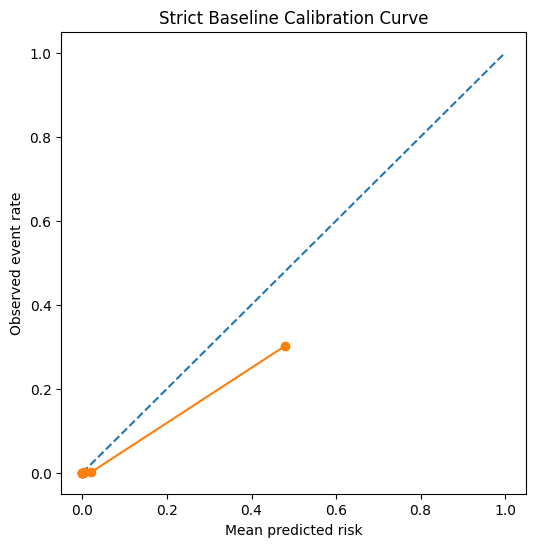


Threshold policy table:


,policy_type,policy,n_flagged,review_share,high_risk_found,precision,recall_capture,false_positives,false_negatives,fp_per_tp
0,threshold,threshold >= 0.50,376,0.0407,276,0.7340,0.9822,100,5,0.3623
1,threshold,threshold >= 0.30,469,0.0507,278,0.5928,0.9893,191,3,0.6871
2,threshold,threshold >= 0.20,561,0.0607,278,0.4955,0.9893,283,3,1.0180
3,threshold,threshold >= 0.10,748,0.0809,279,0.3730,0.9929,469,2,1.6810



Top-k policy table:


,policy_type,policy,n_flagged,review_share,high_risk_found,precision,recall_capture,false_positives,false_negatives,fp_per_tp
0,ranking,top 3% review,277,0.03,267,0.9639,0.9502,10,14,0.0375
1,ranking,top 5% review,462,0.05,278,0.6017,0.9893,184,3,0.6619



Simple daily workload scenarios:


,daily_alert_patients,policy,expected_re_reviews_per_day
0,100,top 3% review,3
1,100,top 5% review,5
2,200,top 3% review,6
3,200,top 5% review,10



Recommended operating posture:


,recommended_setting,suggested_policy,reason
0,resource-limited setting,top 3% review,captures about 95% of hidden high-risk cases w...
1,miss-minimization setting,top 5% review or threshold >= 0.50,captures about 98–99% of hidden high-risk case...


In [21]:
# ------------------------------------------
# 1) Pull strict baseline outputs
# ------------------------------------------
y_valid = strict_result["y_valid"]
pred_proba = strict_result["pred_proba"]

if hasattr(y_valid, "values"):
    y_true = y_valid.values
else:
    y_true = np.array(y_valid)

pred_proba = np.array(pred_proba)

# ------------------------------------------
# 2) Calibration summary
# ------------------------------------------
brier = brier_score_loss(y_true, pred_proba)
frac_pos, mean_pred = calibration_curve(y_true, pred_proba, n_bins=10, strategy="quantile")

print("=" * 100)
print("APPENDIX B — CALIBRATION / THRESHOLD POLICY")
print("=" * 100)
print(f"Brier score: {brier:.6f}")

calib_df = pd.DataFrame({
    "bin_mean_predicted_risk": mean_pred,
    "bin_observed_event_rate": frac_pos,
}).round(4)

print("\nCalibration table:")
display(calib_df)

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], linestyle="--")
plt.plot(mean_pred, frac_pos, marker="o")
plt.xlabel("Mean predicted risk")
plt.ylabel("Observed event rate")
plt.title("Strict Baseline Calibration Curve")
plt.show()

# ------------------------------------------
# 3) Threshold-based policy table
# ------------------------------------------
threshold_rows = []
for th in [0.50, 0.30, 0.20, 0.10]:
    pred = (pred_proba >= th).astype(int)

    tp = int(((pred == 1) & (y_true == 1)).sum())
    fp = int(((pred == 1) & (y_true == 0)).sum())
    fn = int(((pred == 0) & (y_true == 1)).sum())
    tn = int(((pred == 0) & (y_true == 0)).sum())

    n_flagged = int(pred.sum())
    review_share = n_flagged / len(y_true)
    precision = tp / n_flagged if n_flagged > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    fp_per_tp = fp / tp if tp > 0 else np.nan

    threshold_rows.append({
        "policy_type": "threshold",
        "policy": f"threshold >= {th:.2f}",
        "n_flagged": n_flagged,
        "review_share": review_share,
        "high_risk_found": tp,
        "precision": precision,
        "recall_capture": recall,
        "false_positives": fp,
        "false_negatives": fn,
        "fp_per_tp": fp_per_tp,
    })

threshold_df = pd.DataFrame(threshold_rows).round(4)

print("\nThreshold policy table:")
display(threshold_df)

# ------------------------------------------
# 4) Top-k review policy table
# ------------------------------------------
ranked = pd.DataFrame({
    "y_true": y_true,
    "risk_score": pred_proba
}).sort_values("risk_score", ascending=False).reset_index(drop=True)

total_high_risk = int(ranked["y_true"].sum())

topk_rows = []
for pct in [0.03, 0.05]:
    k = max(1, int(len(ranked) * pct))
    topk = ranked.head(k)

    tp = int(topk["y_true"].sum())
    fp = k - tp
    fn = total_high_risk - tp

    precision = tp / k if k > 0 else 0.0
    recall = tp / total_high_risk if total_high_risk > 0 else 0.0
    fp_per_tp = fp / tp if tp > 0 else np.nan

    topk_rows.append({
        "policy_type": "ranking",
        "policy": f"top {int(pct*100)}% review",
        "n_flagged": k,
        "review_share": pct,
        "high_risk_found": tp,
        "precision": precision,
        "recall_capture": recall,
        "false_positives": fp,
        "false_negatives": fn,
        "fp_per_tp": fp_per_tp,
    })

topk_df = pd.DataFrame(topk_rows).round(4)

print("\nTop-k policy table:")
display(topk_df)

# ------------------------------------------
# 5) Daily alert-volume workload scenarios
# ------------------------------------------
scenario_rows = []
for daily_alert_volume in [100, 200]:
    for pct in [0.03, 0.05]:
        n_review = max(1, int(daily_alert_volume * pct))
        scenario_rows.append({
            "daily_alert_patients": daily_alert_volume,
            "policy": f"top {int(pct*100)}% review",
            "expected_re_reviews_per_day": n_review,
        })

scenario_df = pd.DataFrame(scenario_rows)

print("\nSimple daily workload scenarios:")
display(scenario_df)

# ------------------------------------------
# 6) Recommended operating posture
# ------------------------------------------
recommendation_df = pd.DataFrame([
    {
        "recommended_setting": "resource-limited setting",
        "suggested_policy": "top 3% review",
        "reason": "captures about 95% of hidden high-risk cases while keeping the review pool very small"
    },
    {
        "recommended_setting": "miss-minimization setting",
        "suggested_policy": "top 5% review or threshold >= 0.50",
        "reason": "captures about 98–99% of hidden high-risk cases with a moderate review burden"
    },
])

print("\nRecommended operating posture:")
display(recommendation_df)

### Appendix B. Calibration and Policy Interpretation

The calibration analysis suggests that the strict baseline is much stronger as a ranking model than as a literal probability estimator. In particular, the highest-risk bin shows some probability overestimation, indicating that predicted probabilities should be interpreted cautiously in absolute terms.

However, the ranking performance remains extremely strong. This supports the intended deployment framing of the model: not as a standalone triage probability engine, but as a re-review prioritization tool for apparently stable patients. In this setting, a top-3% review policy appears especially attractive when review capacity is limited, while a top-5% policy is more appropriate when minimizing missed urgent cases is the main priority.

## Appendix C. Lightweight Tree-Based Benchmark

As a sensitivity check, I compare the strict logistic regression model against a lightweight tree-based benchmark on the same strict feature set and the same train/validation split.

The goal is not to maximize model complexity, but to test whether a more flexible non-linear model produces a meaningful performance gain over the interpretable logistic baseline.

In [23]:
# ------------------------------------------
# 1) Use the same strict feature set
# ------------------------------------------
compare_df = alert_df.copy()

if "high_risk" not in compare_df.columns:
    compare_df["high_risk"] = (compare_df["triage_acuity"] <= 2).astype(int)

strict_features = [
    "age",
    "sex",
    "arrival_mode",
    "arrival_hour",
    "systolic_bp",
    "diastolic_bp",
    "heart_rate",
    "respiratory_rate",
    "temperature_c",
    "spo2",
    "gcs_total",
    "pain_score",
]
strict_features = [c for c in strict_features if c in compare_df.columns]

X_all = compare_df[strict_features].copy()
y_all = compare_df["high_risk"].copy()

if "pain_score" in X_all.columns:
    X_all["pain_score"] = X_all["pain_score"].replace(-1, np.nan)

# ------------------------------------------
# 2) Same split as strict baseline
# ------------------------------------------
train_idx, valid_idx = train_test_split(
    compare_df.index,
    test_size=0.2,
    random_state=42,
    stratify=y_all
)

X_train = X_all.loc[train_idx].copy()
X_valid = X_all.loc[valid_idx].copy()
y_train = y_all.loc[train_idx].copy()
y_valid = y_all.loc[valid_idx].copy()

# ------------------------------------------
# 3) Shared preprocessing
# ------------------------------------------
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = [c for c in X_train.columns if c not in cat_cols]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

# ------------------------------------------
# 4) Logistic baseline on the strict feature set
# ------------------------------------------
logit_model = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

logit_model.fit(X_train, y_train)
logit_proba = logit_model.predict_proba(X_valid)[:, 1]
logit_pred = (logit_proba >= 0.50).astype(int)

# ------------------------------------------
# 5) Random Forest benchmark
# ------------------------------------------
rf_model = Pipeline([
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=3,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)
rf_proba = rf_model.predict_proba(X_valid)[:, 1]
rf_pred = (rf_proba >= 0.50).astype(int)

# ------------------------------------------
# 6) Compare core metrics
# ------------------------------------------
def summarize_model(name, y_true, pred_proba, pred_label):
    cm = confusion_matrix(y_true, pred_label)
    tn, fp, fn, tp = cm.ravel()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    ranked = pd.DataFrame({
        "y_true": y_true.values if hasattr(y_true, "values") else np.array(y_true),
        "risk_score": pred_proba
    }).sort_values("risk_score", ascending=False).reset_index(drop=True)

    total_high_risk = ranked["y_true"].sum()

    def topk_capture(pct):
        k = max(1, int(len(ranked) * pct))
        topk = ranked.head(k)
        found = int(topk["y_true"].sum())
        precision_topk = topk["y_true"].mean()
        capture = found / total_high_risk if total_high_risk > 0 else 0.0
        return k, found, precision_topk, capture

    _, found3, prec3, cap3 = topk_capture(0.03)
    _, found5, prec5, cap5 = topk_capture(0.05)

    return {
        "model": name,
        "feature_set": "strict (12 raw features)",
        "roc_auc": roc_auc_score(y_true, pred_proba),
        "pr_auc": average_precision_score(y_true, pred_proba),
        "precision_at_050": precision,
        "recall_at_050": recall,
        "top3_capture": cap3,
        "top3_precision": prec3,
        "top5_capture": cap5,
        "top5_precision": prec5,
    }

compare_table = pd.DataFrame([
    summarize_model("Logistic Regression", y_valid, logit_proba, logit_pred),
    summarize_model("Random Forest", y_valid, rf_proba, rf_pred),
]).round(4)

print("=" * 100)
print("APPENDIX C — LIGHTWEIGHT TREE-BASED BENCHMARK")
print("=" * 100)
display(compare_table)

# ------------------------------------------
# 7) Optional: show threshold-0.50 confusion matrices
# ------------------------------------------
print("\nConfusion Matrix @ 0.50 — Logistic Regression")
print(confusion_matrix(y_valid, logit_pred))

print("\nConfusion Matrix @ 0.50 — Random Forest")
print(confusion_matrix(y_valid, rf_pred))

APPENDIX C — LIGHTWEIGHT TREE-BASED BENCHMARK


,model,feature_set,roc_auc,pr_auc,precision_at_050,recall_at_050,top3_capture,top3_precision,top5_capture,top5_precision
0,Logistic Regression,strict (12 raw features),0.9985,0.9855,0.7340,0.9822,0.9502,0.9639,0.9893,0.6017
1,Random Forest,strict (12 raw features),0.9997,0.9934,0.9962,0.9217,0.9466,0.9603,0.9964,0.6061



Confusion Matrix @ 0.50 — Logistic Regression
[[8862  100]
 [   5  276]]

Confusion Matrix @ 0.50 — Random Forest
[[8961    1]
 [  22  259]]


### Appendix C. Benchmark Comparison Summary

The lightweight tree-based benchmark slightly outperforms the strict logistic baseline in overall discrimination, achieving higher ROC-AUC and PR-AUC. At the default threshold of 0.50, it also produces substantially fewer false positives than logistic regression. However, this comes at the cost of lower recall, meaning that more hidden high-risk cases are missed.

This trade-off is important for the intended use case of the project. The goal here is not to minimize false alarms at all costs, but to function as a secondary re-review safety-net for apparently stable patients. In that context, the strict logistic model remains attractive because it recovers more hidden high-risk cases at the default threshold, while preserving nearly identical ranking performance in the top-k review setting.

Most importantly, the top-k operating results are very similar between the two models. Both models recover the large majority of hidden high-risk cases when only a small fraction of alert patients are re-reviewed. This suggests that the main project finding does not depend strongly on the choice between a simple linear model and a lightweight non-linear benchmark.

Taken together, these results support the use of logistic regression as the primary model in this project. Although the tree-based benchmark is slightly stronger in overall discrimination, the gain is limited in practical ranking terms, while logistic regression offers a clearer and more clinically interpretable decision structure.

## Appendix D. False Negative Deep Dive

This appendix examines the small set of urgent cases missed by the strict baseline in more detail. The goal is to identify whether the remaining errors cluster around specific complaint types, demographic subgroups, or less extreme physiological presentations, and whether broader structured features may help recover some of these cases.

In [24]:
# =========================================
# APPENDIX D — FALSE NEGATIVE DEEP DIVE
# =========================================

# -------------------------------------------------
# 1) Rebuild the same strict split and attach metadata
# -------------------------------------------------
fn_df = alert_df.copy()

if "high_risk" not in fn_df.columns:
    fn_df["high_risk"] = (fn_df["triage_acuity"] <= 2).astype(int)

X_strict = fn_df[strict_features].copy()
y_strict = fn_df["high_risk"].copy()

if "pain_score" in X_strict.columns:
    X_strict["pain_score"] = X_strict["pain_score"].replace(-1, np.nan)

train_idx, valid_idx = train_test_split(
    fn_df.index,
    test_size=0.2,
    random_state=42,
    stratify=y_strict
)

valid_meta = fn_df.loc[valid_idx].copy()
y_valid = strict_result["y_valid"]
strict_pred_proba = np.array(strict_result["pred_proba"])
strict_pred_050 = (strict_pred_proba >= 0.50).astype(int)

valid_meta["y_true"] = y_valid.values if hasattr(y_valid, "values") else np.array(y_valid)
valid_meta["strict_risk_score"] = strict_pred_proba
valid_meta["strict_pred_050"] = strict_pred_050

false_negatives = valid_meta[(valid_meta["y_true"] == 1) & (valid_meta["strict_pred_050"] == 0)].copy()
false_positives = valid_meta[(valid_meta["y_true"] == 0) & (valid_meta["strict_pred_050"] == 1)].copy()
true_positives = valid_meta[(valid_meta["y_true"] == 1) & (valid_meta["strict_pred_050"] == 1)].copy()

print("=" * 100)
print("APPENDIX D — FALSE NEGATIVE DEEP DIVE")
print("=" * 100)
print("False negatives @ 0.50:", len(false_negatives))
print("False positives @ 0.50:", len(false_positives))
print("True positives @ 0.50:", len(true_positives))

# -------------------------------------------------
# 2) False negative sample rows
# -------------------------------------------------
review_cols = [
    "patient_id",
    "triage_acuity",
    "strict_risk_score",
    "age",
    "age_group",
    "sex",
    "arrival_mode",
    "arrival_hour",
    "systolic_bp",
    "diastolic_bp",
    "heart_rate",
    "respiratory_rate",
    "temperature_c",
    "spo2",
    "gcs_total",
    "pain_score",
    "chief_complaint_system",
    "chief_complaint_raw",
]
review_cols = [c for c in review_cols if c in false_negatives.columns]

print("\nFalse negative sample rows:")
display(false_negatives[review_cols].sort_values("strict_risk_score", ascending=True))

# -------------------------------------------------
# 3) FN vs TP physiology comparison
# -------------------------------------------------
compare_cols = [c for c in [
    "age",
    "systolic_bp", "diastolic_bp",
    "heart_rate", "respiratory_rate", "temperature_c",
    "spo2", "gcs_total", "pain_score"
] if c in valid_meta.columns]

fn_vs_tp = pd.DataFrame({
    "false_negative_mean": false_negatives[compare_cols].mean(),
    "true_positive_mean": true_positives[compare_cols].mean(),
    "all_high_risk_mean": valid_meta.loc[valid_meta["y_true"] == 1, compare_cols].mean(),
}).round(3)

print("\nFalse negatives vs true positives summary:")
display(fn_vs_tp)

# Difference table
if len(false_negatives) > 0 and len(true_positives) > 0:
    diff_df = pd.DataFrame({
        "fn_minus_tp": (false_negatives[compare_cols].mean() - true_positives[compare_cols].mean()).round(3)
    }).sort_values("fn_minus_tp")
    print("\nFalse negative minus true positive differences:")
    display(diff_df)

# -------------------------------------------------
# 4) Complaint / subgroup concentration
# -------------------------------------------------
for col in ["chief_complaint_system", "arrival_mode", "sex", "age_group"]:
    if col in valid_meta.columns:
        print(f"\nFalse negatives by {col}:")
        display(false_negatives[col].value_counts(dropna=False).to_frame("fn_count"))

# -------------------------------------------------
# 5) Subgroup-level FN rate among actual high-risk patients
#    (Within each subgroup, among true high-risk only, what share was missed?)
# -------------------------------------------------
high_risk_valid = valid_meta[valid_meta["y_true"] == 1].copy()
high_risk_valid["is_false_negative"] = (high_risk_valid["strict_pred_050"] == 0).astype(int)

for col in ["chief_complaint_system", "arrival_mode", "sex", "age_group"]:
    if col in high_risk_valid.columns:
        subgroup_fn = (
            high_risk_valid.groupby(col)["is_false_negative"]
            .agg(["mean", "count", "sum"])
            .rename(columns={"mean": "fn_rate_within_high_risk", "sum": "n_false_negatives"})
            .sort_values(["fn_rate_within_high_risk", "count"], ascending=[False, False])
            .round(4)
        )
        print(f"\nSubgroup false-negative rate among actual high-risk cases — {col}:")
        display(subgroup_fn.head(15))

# -------------------------------------------------
# 6) Broad-vs-strict rescue check
#    Did the broader model rescue cases missed by the strict model?
# -------------------------------------------------
# Rebuild the same broad baseline feature set
broad_df = alert_df.copy()

if "pain_score_missing_flag" not in broad_df.columns and "pain_score" in broad_df.columns:
    broad_df["pain_score_missing_flag"] = (broad_df["pain_score"] == -1).astype(int)

for col in ["systolic_bp", "diastolic_bp", "respiratory_rate", "temperature_c"]:
    flag_col = f"{col}_missing_flag"
    if col in broad_df.columns and flag_col not in broad_df.columns:
        broad_df[flag_col] = broad_df[col].isna().astype(int)

broad_drop_cols = [
    "patient_id",
    "triage_nurse_id",
    "site_id",
    "triage_acuity",
    "high_risk",
    "disposition",
    "ed_los_hours",
    "chief_complaint_raw",
]
broad_features = [c for c in broad_df.columns if c not in broad_drop_cols]

# same split
X_broad_train = broad_df.loc[train_idx, broad_features].copy()
X_broad_valid = broad_df.loc[valid_idx, broad_features].copy()
y_broad_train = broad_df.loc[train_idx, "high_risk"].copy()
y_broad_valid = broad_df.loc[valid_idx, "high_risk"].copy()

if "pain_score" in X_broad_train.columns:
    X_broad_train["pain_score"] = X_broad_train["pain_score"].replace(-1, np.nan)
    X_broad_valid["pain_score"] = X_broad_valid["pain_score"].replace(-1, np.nan)

cat_cols_b = X_broad_train.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols_b = [c for c in X_broad_train.columns if c not in cat_cols_b]

numeric_transformer_b = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_b = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_b = ColumnTransformer([
    ("num", numeric_transformer_b, num_cols_b),
    ("cat", categorical_transformer_b, cat_cols_b)
])

broad_model = Pipeline([
    ("prep", preprocessor_b),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

broad_model.fit(X_broad_train, y_broad_train)
broad_pred_proba = broad_model.predict_proba(X_broad_valid)[:, 1]
broad_pred_050 = (broad_pred_proba >= 0.50).astype(int)

valid_meta["broad_risk_score"] = broad_pred_proba
valid_meta["broad_pred_050"] = broad_pred_050

fn_broad_compare = valid_meta[(valid_meta["y_true"] == 1) & (valid_meta["strict_pred_050"] == 0)].copy()
fn_broad_compare["rescued_by_broad"] = (fn_broad_compare["broad_pred_050"] == 1).astype(int)

print("\nStrict false negatives rescued by broad baseline:")
if len(fn_broad_compare) > 0:
    rescue_cols = [c for c in [
        "patient_id",
        "triage_acuity",
        "strict_risk_score",
        "broad_risk_score",
        "rescued_by_broad",
        "chief_complaint_system",
        "chief_complaint_raw"
    ] if c in fn_broad_compare.columns]
    display(fn_broad_compare[rescue_cols].sort_values("broad_risk_score", ascending=False))
    print("Number rescued by broad baseline:", int(fn_broad_compare["rescued_by_broad"].sum()), "out of", len(fn_broad_compare))
else:
    print("No strict false negatives found.")

# -------------------------------------------------
# 7) FN takeaway helper table
# -------------------------------------------------
takeaway_rows = []

if len(false_negatives) > 0 and len(true_positives) > 0:
    takeaway_rows.append({
        "finding": "n_false_negatives",
        "value": len(false_negatives)
    })
    takeaway_rows.append({
        "finding": "fn_mean_age",
        "value": round(false_negatives["age"].mean(), 2) if "age" in false_negatives.columns else np.nan
    })
    takeaway_rows.append({
        "finding": "tp_mean_age",
        "value": round(true_positives["age"].mean(), 2) if "age" in true_positives.columns else np.nan
    })
    takeaway_rows.append({
        "finding": "fn_mean_gcs",
        "value": round(false_negatives["gcs_total"].mean(), 2) if "gcs_total" in false_negatives.columns else np.nan
    })
    takeaway_rows.append({
        "finding": "tp_mean_gcs",
        "value": round(true_positives["gcs_total"].mean(), 2) if "gcs_total" in true_positives.columns else np.nan
    })
    takeaway_rows.append({
        "finding": "n_rescued_by_broad",
        "value": int(fn_broad_compare["rescued_by_broad"].sum()) if len(fn_broad_compare) > 0 else 0
    })

takeaway_df = pd.DataFrame(takeaway_rows)
print("\nFalse-negative takeaway summary:")
display(takeaway_df)

APPENDIX D — FALSE NEGATIVE DEEP DIVE
False negatives @ 0.50: 5
False positives @ 0.50: 100
True positives @ 0.50: 276

False negative sample rows:


,patient_id,triage_acuity,strict_risk_score,age,age_group,sex,arrival_mode,arrival_hour,systolic_bp,diastolic_bp,heart_rate,respiratory_rate,temperature_c,spo2,gcs_total,pain_score,chief_complaint_system,chief_complaint_raw
73842,TG-PHILDEX0J,2,0.003444,63,middle_aged,M,brought_by_family,4,82.9,82.4,76.4,14.1,36.5,92.0,15,9,dermatological,eczema herpeticum
1226,TG-D5EZU80WJ,2,0.042907,55,middle_aged,M,ambulance,6,108.8,75.0,91.4,24.9,37.5,99.8,15,5,musculoskeletal,"open fracture with contamination, no prior his..."
12019,TG-WV7C4QDR8,2,0.148765,63,middle_aged,F,walk-in,12,109.7,65.0,51.7,16.4,37.0,89.9,15,10,cardiovascular,acute NSTEMI，worsening over hours
54918,TG-VSEKLPQGW,2,0.390022,55,middle_aged,M,brought_by_family,11,114.2,54.7,122.9,16.2,39.0,91.8,15,6,dermatological,"bullous pemphigoid acute, onset today"
32316,TG-FTK0OW995,2,0.477472,83,elderly,F,walk-in,14,104.2,48.8,147.6,25.1,36.5,98.5,15,6,neurological,"acute altered mental status, onset today"



False negatives vs true positives summary:


,false_negative_mean,true_positive_mean,all_high_risk_mean
age,63.80,47.040,47.338
systolic_bp,103.96,100.810,100.866
diastolic_bp,65.18,62.467,62.515
heart_rate,98.00,109.278,109.077
respiratory_rate,19.34,23.431,23.358
temperature_c,37.30,38.504,38.482
spo2,94.40,90.851,90.915
gcs_total,15.00,11.873,11.929
pain_score,7.20,7.928,7.915



False negative minus true positive differences:


...

,fn_rate_within_high_risk,count,n_false_negatives
age_group,,,
middle_aged,0.0377,106,4
elderly,0.0152,66,1
young_adult,0.0000,84,0
pediatric,0.0000,25,0



Strict false negatives rescued by broad baseline:


,patient_id,triage_acuity,strict_risk_score,broad_risk_score,rescued_by_broad,chief_complaint_system,chief_complaint_raw
54918,TG-VSEKLPQGW,2,0.390022,0.967313,1,dermatological,"bullous pemphigoid acute, onset today"
12019,TG-WV7C4QDR8,2,0.148765,0.880678,1,cardiovascular,acute NSTEMI，worsening over hours
32316,TG-FTK0OW995,2,0.477472,0.804899,1,neurological,"acute altered mental status, onset today"
1226,TG-D5EZU80WJ,2,0.042907,0.274548,0,musculoskeletal,"open fracture with contamination, no prior his..."
73842,TG-PHILDEX0J,2,0.003444,0.009509,0,dermatological,eczema herpeticum


Number rescued by broad baseline: 3 out of 5

False-negative takeaway summary:


,finding,value
0,n_false_negatives,5.00
1,fn_mean_age,63.80
2,tp_mean_age,47.04
3,fn_mean_gcs,15.00
4,tp_mean_gcs,11.87
5,n_rescued_by_broad,3.00


### Appendix D. False Negative Deep-Dive Summary

The false negative review suggests that the strict baseline does not mainly fail on obviously unstable urgent cases. Instead, the missed cases appear to be physiologically subtler: compared with true positives, they are older on average, have fully normal GCS values, and show less extreme abnormalities in heart rate, respiratory rate, temperature, and oxygen saturation.

This pattern suggests an important limitation of the physiology-only design. Some urgent cases may not express their risk primarily through severe vital-sign disruption at triage, especially when complaint semantics or broader clinical context carry part of the urgency signal. The complaint distribution of the missed cases is consistent with this interpretation, although the subgroup counts are small and should be interpreted cautiously.

The rescue comparison is especially informative: the broader baseline recovers 3 of the 5 strict-model false negatives. This suggests that while the main hidden-risk signal is largely physiological, broader structured context may still provide incremental value for the most difficult borderline cases.

## Appendix E. Subgroup Robustness

To check whether the strict baseline performs consistently across different patient groups, I evaluate its behavior across a small set of clinically relevant subgroups. The goal is not to make strong fairness claims from a synthetic dataset, but to identify whether performance appears concentrated in only a narrow subset of the alert population.

APPENDIX E — SUBGROUP ROBUSTNESS

Subgroup performance by sex:


,sex,n_valid,high_risk_prevalence,n_high_risk,n_flagged_050,precision_at_050,recall_at_050,pr_auc,roc_auc,false_negatives,false_positives
0,F,4720,0.0314,148,211,0.6919,0.9865,0.9900,0.9995,2,65
1,M,4314,0.0301,130,162,0.7840,0.9769,0.9809,0.9976,3,35
2,Other,209,0.0144,3,3,1.0000,1.0000,1.0000,1.0000,0,0



Subgroup performance by age_group:


,age_group,n_valid,high_risk_prevalence,n_high_risk,n_flagged_050,precision_at_050,recall_at_050,pr_auc,roc_auc,false_negatives,false_positives
0,middle_aged,3154,0.0336,106,139,0.7338,0.9623,0.9740,0.9963,4,37
1,young_adult,2794,0.0301,84,117,0.7179,1.0000,0.9906,0.9996,0,33
2,elderly,2529,0.0261,66,84,0.7738,0.9848,0.9963,0.9999,1,19
3,pediatric,766,0.0326,25,36,0.6944,1.0000,0.9865,0.9995,0,11



Subgroup performance by arrival_mode:


,arrival_mode,n_valid,high_risk_prevalence,n_high_risk,n_flagged_050,precision_at_050,recall_at_050,pr_auc,roc_auc,false_negatives,false_positives
0,walk-in,4427,0.0337,149,193,0.7617,0.9866,0.9892,0.9994,2,46
1,ambulance,2601,0.0238,62,92,0.6630,0.9839,0.9791,0.9984,1,31
2,transfer,906,0.0298,27,40,0.6750,1.0000,1.0000,1.0000,0,13
3,brought_by_family,628,0.0366,23,23,0.9130,0.9130,0.9586,0.9950,2,2
4,police,381,0.0236,9,12,0.7500,1.0000,1.0000,1.0000,0,3
5,helicopter,300,0.0367,11,16,0.6875,1.0000,1.0000,1.0000,0,5



Subgroup performance by chief_complaint_system:


,chief_complaint_system,n_valid,high_risk_prevalence,n_high_risk,n_flagged_050,precision_at_050,recall_at_050,pr_auc,roc_auc,false_negatives,false_positives
0,infectious,691,0.0405,28,34,0.8235,1.0000,0.9900,0.9995,0,6
1,respiratory,690,0.0493,34,41,0.8293,1.0000,1.0000,1.0000,0,7
2,musculoskeletal,686,0.0277,19,25,0.7200,0.9474,0.9605,0.9955,1,7
3,endocrine,685,0.0277,19,28,0.6786,1.0000,0.9974,0.9999,0,9
4,dermatological,669,0.0209,14,20,0.6000,0.8571,0.8990,0.9824,2,8
5,ophthalmic,668,0.0150,10,17,0.5882,1.0000,1.0000,1.0000,0,7
6,gastrointestinal,660,0.0364,24,32,0.7500,1.0000,0.9923,0.9997,0,8
7,trauma,656,0.0290,19,22,0.8636,1.0000,1.0000,1.0000,0,3
8,neurological,655,0.0260,17,25,0.6400,0.9412,0.9769,0.9990,1,9
9,cardiovascular,650,0.0292,19,25,0.7200,0.9474,0.9655,0.9979,1,7



Compact recall-focused subgroup comparison:


,group_type,sex,n_valid,high_risk_prevalence,recall_at_050,precision_at_050,false_negatives,age_group,arrival_mode,chief_complaint_system
0,sex,F,4720,0.0314,0.9865,0.6919,2,NaN,NaN,NaN
1,sex,M,4314,0.0301,0.9769,0.7840,3,NaN,NaN,NaN
2,sex,Other,209,0.0144,1.0000,1.0000,0,NaN,NaN,NaN
3,age_group,NaN,3154,0.0336,0.9623,0.7338,4,middle_aged,NaN,NaN
4,age_group,NaN,2794,0.0301,1.0000,0.7179,0,young_adult,NaN,NaN
5,age_group,NaN,2529,0.0261,0.9848,0.7738,1,elderly,NaN,NaN
6,age_group,NaN,766,0.0326,1.0000,0.6944,0,pediatric,NaN,NaN
7,arrival_mode,NaN,4427,0.0337,0.9866,0.7617,2,NaN,walk-in,NaN
8,arrival_mode,NaN,2601,0.0238,0.9839,0.6630,1,NaN,ambulance,NaN
9,arrival_mode,NaN,906,0.0298,1.0000,0.6750,0,NaN,transfer,NaN


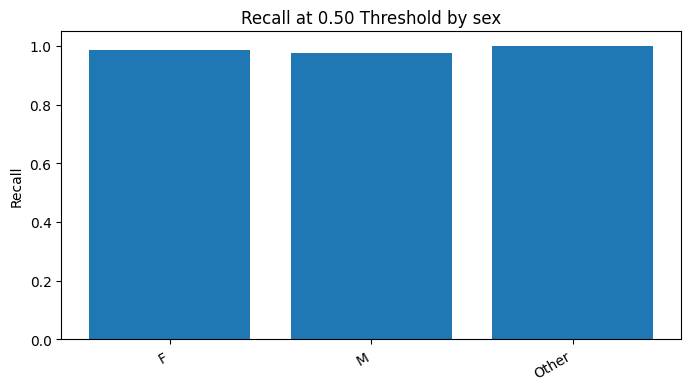

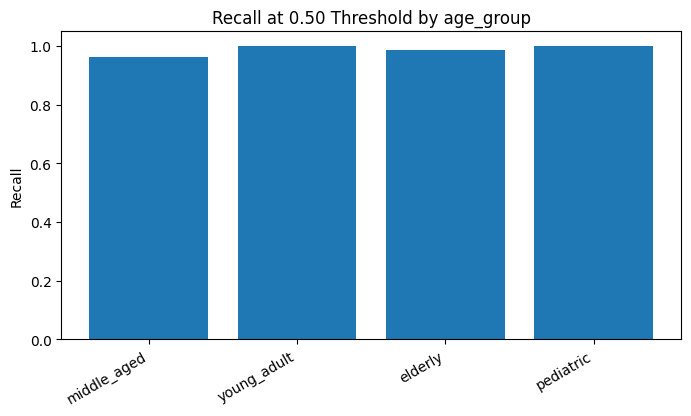

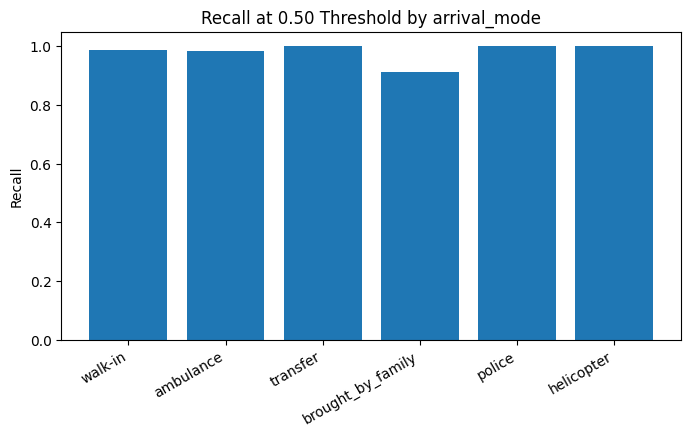

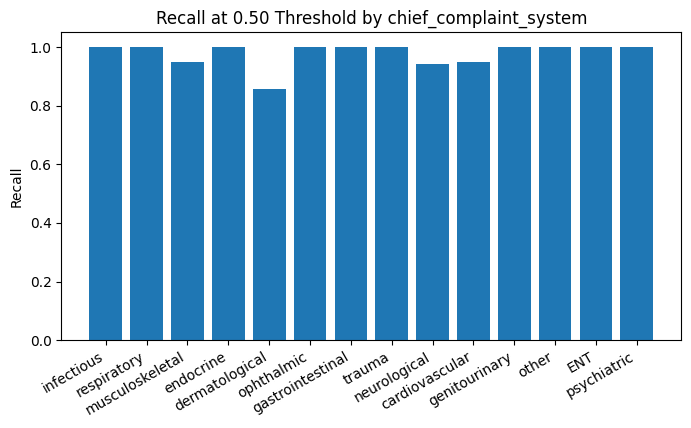

In [25]:
# =========================================
# APPENDIX E — SUBGROUP ROBUSTNESS
# =========================================

# -------------------------------------------------
# 1) Rebuild the same strict validation set
# -------------------------------------------------
robust_df = alert_df.copy()

if "high_risk" not in robust_df.columns:
    robust_df["high_risk"] = (robust_df["triage_acuity"] <= 2).astype(int)

X_strict = robust_df[strict_features].copy()
y_strict = robust_df["high_risk"].copy()

if "pain_score" in X_strict.columns:
    X_strict["pain_score"] = X_strict["pain_score"].replace(-1, np.nan)

train_idx, valid_idx = train_test_split(
    robust_df.index,
    test_size=0.2,
    random_state=42,
    stratify=y_strict
)

valid_meta = robust_df.loc[valid_idx].copy()
y_valid = strict_result["y_valid"]
pred_proba = np.array(strict_result["pred_proba"])
pred_050 = (pred_proba >= 0.50).astype(int)

valid_meta["y_true"] = y_valid.values if hasattr(y_valid, "values") else np.array(y_valid)
valid_meta["pred_050"] = pred_050
valid_meta["risk_score"] = pred_proba

# -------------------------------------------------
# 2) Function to summarize subgroup performance
# -------------------------------------------------
def subgroup_summary(df, group_col):
    rows = []
    for g, sub in df.groupby(group_col):
        n = len(sub)
        positives = int(sub["y_true"].sum())
        flagged = int(sub["pred_050"].sum())

        tp = int(((sub["pred_050"] == 1) & (sub["y_true"] == 1)).sum())
        fp = int(((sub["pred_050"] == 1) & (sub["y_true"] == 0)).sum())
        fn = int(((sub["pred_050"] == 0) & (sub["y_true"] == 1)).sum())

        prevalence = positives / n if n > 0 else np.nan
        precision = tp / flagged if flagged > 0 else np.nan
        recall = tp / positives if positives > 0 else np.nan

        # PR-AUC only makes sense if both classes exist
        if sub["y_true"].nunique() == 2:
            pr_auc = average_precision_score(sub["y_true"], sub["risk_score"])
            roc_auc = roc_auc_score(sub["y_true"], sub["risk_score"])
        else:
            pr_auc = np.nan
            roc_auc = np.nan

        rows.append({
            group_col: g,
            "n_valid": n,
            "high_risk_prevalence": prevalence,
            "n_high_risk": positives,
            "n_flagged_050": flagged,
            "precision_at_050": precision,
            "recall_at_050": recall,
            "pr_auc": pr_auc,
            "roc_auc": roc_auc,
            "false_negatives": fn,
            "false_positives": fp,
        })

    out = pd.DataFrame(rows).sort_values("n_valid", ascending=False).reset_index(drop=True)
    return out.round(4)

# -------------------------------------------------
# 3) Run subgroup checks
# -------------------------------------------------
group_cols = ["sex", "age_group", "arrival_mode", "chief_complaint_system"]

print("=" * 100)
print("APPENDIX E — SUBGROUP ROBUSTNESS")
print("=" * 100)

subgroup_tables = {}

for col in group_cols:
    if col in valid_meta.columns:
        print(f"\nSubgroup performance by {col}:")
        subgroup_tables[col] = subgroup_summary(valid_meta, col)
        display(subgroup_tables[col])

# -------------------------------------------------
# 4) Compact comparison table: recall-focused view
# -------------------------------------------------
compact_rows = []
for col, df_out in subgroup_tables.items():
    tmp = df_out.copy()
    tmp["group_type"] = col
    compact_rows.append(tmp[["group_type", col, "n_valid", "high_risk_prevalence", "recall_at_050", "precision_at_050", "false_negatives"]])

if len(compact_rows) > 0:
    compact_df = pd.concat(compact_rows, axis=0).reset_index(drop=True)
    print("\nCompact recall-focused subgroup comparison:")
    display(compact_df)

# -------------------------------------------------
# 5) Simple visual: subgroup recall at 0.50
# -------------------------------------------------
for col, df_out in subgroup_tables.items():
    plot_df = df_out.dropna(subset=["recall_at_050"]).copy()
    if len(plot_df) > 0:
        plt.figure(figsize=(8, 4))
        plt.bar(plot_df[col].astype(str), plot_df["recall_at_050"])
        plt.title(f"Recall at 0.50 Threshold by {col}")
        plt.ylabel("Recall")
        plt.ylim(0, 1.05)
        plt.xticks(rotation=30, ha="right")
        plt.show()

### Appendix E. Subgroup Robustness Summary

The subgroup robustness analysis suggests that the strict baseline performs strongly across most major patient groups rather than only within a narrow subset of the alert population. Recall at the 0.50 threshold remains very high across sex groups, age groups, arrival modes, and most chief complaint systems, which supports the interpretation that the model is learning a broadly useful physiological signal rather than overfitting to a single subgroup.

At the same time, the subgroup tables reveal several weaker pockets of performance. In particular, recall is somewhat lower in the `dermatological` subgroup, and modestly lower in `neurological`, `cardiovascular`, `musculoskeletal`, and `brought_by_family` cases. This pattern is consistent with the earlier false-negative review: some urgent cases may be harder to detect when their risk is not expressed primarily through extreme physiological instability alone.

Across demographic groups, performance remains strong overall. Recall is high for both female and male patients, and also remains strong across age groups, although the `middle_aged` subgroup shows slightly more missed cases than other age groups. These differences are not large enough to overturn the main project conclusion, but they do suggest that errors are not distributed perfectly uniformly across the alert population.

Because some subgroup sample sizes are small, these results should be interpreted as robustness checks rather than definitive fairness claims. Still, the overall pattern is reassuring: the model appears broadly stable across the main triage subgroups, while the remaining blind spots are concentrated in a limited number of subtler complaint categories rather than reflecting a general collapse of performance.

## Appendix F. Workflow Sensitivity Analysis

To make the re-review policy easier to interpret operationally, I project several candidate policies into simple daily alert-volume scenarios. The goal is not to estimate exact hospital throughput, but to translate model performance into approximate review burden, hidden high-risk recovery, and false-positive workload under different capacity settings.

APPENDIX F — WORKFLOW SENSITIVITY ANALYSIS
Validation sample size: 9243
Hidden high-risk prevalence in alert subgroup: 0.0304

Candidate policy performance table:


,policy_type,policy,flagged_share,precision,recall_capture,specificity,false_positive_per_true_positive
0,threshold,threshold >= 0.50,0.0407,0.7340,0.9822,0.9888,0.3623
1,threshold,threshold >= 0.30,0.0507,0.5928,0.9893,0.9787,0.6871
2,ranking,top 3% review,0.0300,0.9639,0.9502,0.9989,0.0375
3,ranking,top 5% review,0.0500,0.6017,0.9893,0.9795,0.6619



Projected daily workflow scenarios:


,daily_alert_patients,policy,expected_re_reviews_per_day,expected_hidden_high_risk_per_day,expected_hidden_high_risk_found,expected_hidden_high_risk_missed,expected_false_positive_reviews
0,100,threshold >= 0.50,4.07,3.04,2.99,0.05,1.08
1,100,threshold >= 0.30,5.07,3.04,3.01,0.03,2.06
2,100,top 3% review,3.00,3.04,2.89,0.15,0.11
3,100,top 5% review,5.00,3.04,3.01,0.03,1.99
4,200,threshold >= 0.50,8.14,6.08,5.97,0.11,2.17
5,200,threshold >= 0.30,10.14,6.08,6.02,0.07,4.12
6,200,top 3% review,6.00,6.08,5.78,0.30,0.22
7,200,top 5% review,10.00,6.08,6.02,0.07,3.98
8,300,threshold >= 0.50,12.21,9.12,8.96,0.16,3.25
9,300,threshold >= 0.30,15.21,9.12,9.02,0.10,6.19



Suggested operating postures:


,setting,recommended_policy,why
0,resource-limited,top 3% review,small review pool with strong hidden-risk capture
1,balanced,threshold >= 0.50,very high recall with better precision than lo...
2,miss-minimization,top 5% review or threshold >= 0.30,captures nearly all hidden high-risk cases at ...


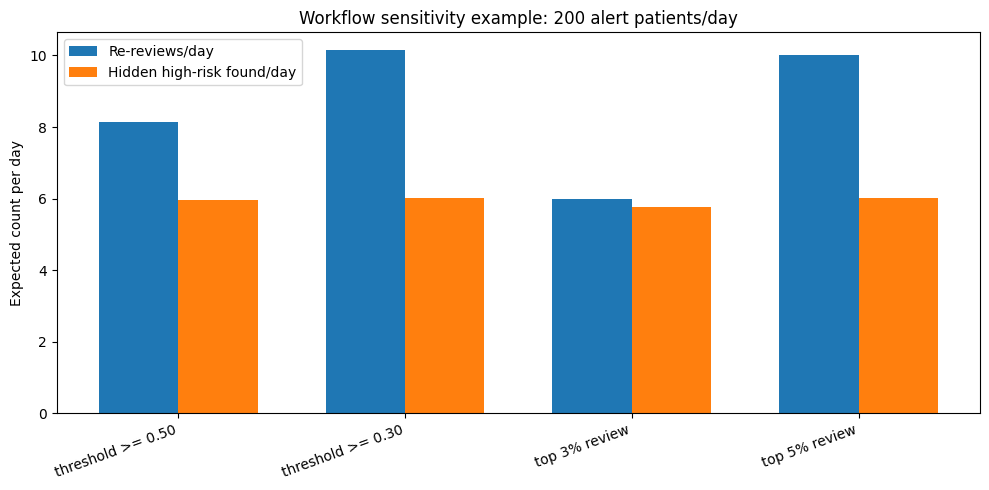

In [26]:
# =========================================
# APPENDIX F — WORKFLOW SENSITIVITY ANALYSIS
# =========================================

# -------------------------------------------------
# 1) Pull strict baseline validation outputs
# -------------------------------------------------
y_valid = strict_result["y_valid"]
pred_proba = np.array(strict_result["pred_proba"])

y_true = y_valid.values if hasattr(y_valid, "values") else np.array(y_valid)
n_valid = len(y_true)
prevalence = y_true.mean()

print("=" * 100)
print("APPENDIX F — WORKFLOW SENSITIVITY ANALYSIS")
print("=" * 100)
print(f"Validation sample size: {n_valid}")
print(f"Hidden high-risk prevalence in alert subgroup: {prevalence:.4f}")

# -------------------------------------------------
# 2) Build candidate policy table
# -------------------------------------------------
policy_rows = []

# threshold policies
for th in [0.50, 0.30]:
    pred = (pred_proba >= th).astype(int)
    tp = int(((pred == 1) & (y_true == 1)).sum())
    fp = int(((pred == 1) & (y_true == 0)).sum())
    fn = int(((pred == 0) & (y_true == 1)).sum())
    tn = int(((pred == 0) & (y_true == 0)).sum())

    n_flagged = int(pred.sum())
    flagged_share = n_flagged / n_valid
    precision = tp / n_flagged if n_flagged > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    policy_rows.append({
        "policy_type": "threshold",
        "policy": f"threshold >= {th:.2f}",
        "flagged_share": flagged_share,
        "precision": precision,
        "recall_capture": recall,
        "specificity": specificity,
        "false_positive_per_true_positive": fp / tp if tp > 0 else np.nan,
    })

# ranking policies
ranked = pd.DataFrame({
    "y_true": y_true,
    "risk_score": pred_proba
}).sort_values("risk_score", ascending=False).reset_index(drop=True)

for pct in [0.03, 0.05]:
    k = max(1, int(n_valid * pct))
    topk = ranked.head(k)

    tp = int(topk["y_true"].sum())
    fp = k - tp
    fn = int(y_true.sum()) - tp
    tn = (n_valid - k) - fn

    flagged_share = k / n_valid
    precision = tp / k if k > 0 else 0.0
    recall = tp / y_true.sum() if y_true.sum() > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    policy_rows.append({
        "policy_type": "ranking",
        "policy": f"top {int(pct*100)}% review",
        "flagged_share": flagged_share,
        "precision": precision,
        "recall_capture": recall,
        "specificity": specificity,
        "false_positive_per_true_positive": fp / tp if tp > 0 else np.nan,
    })

policy_df = pd.DataFrame(policy_rows).round(4)
print("\nCandidate policy performance table:")
display(policy_df)

# -------------------------------------------------
# 3) Project into daily alert-volume scenarios
# -------------------------------------------------
daily_alert_volumes = [100, 200, 300]

scenario_rows = []
for daily_alerts in daily_alert_volumes:
    expected_high_risk = daily_alerts * prevalence

    for _, row in policy_df.iterrows():
        flagged = daily_alerts * row["flagged_share"]
        high_risk_found = expected_high_risk * row["recall_capture"]
        missed_high_risk = expected_high_risk - high_risk_found

        # flagged = TP + FP  =>  FP = flagged - TP
        false_positive_reviews = max(0.0, flagged - high_risk_found)

        scenario_rows.append({
            "daily_alert_patients": daily_alerts,
            "policy": row["policy"],
            "expected_re_reviews_per_day": flagged,
            "expected_hidden_high_risk_per_day": expected_high_risk,
            "expected_hidden_high_risk_found": high_risk_found,
            "expected_hidden_high_risk_missed": missed_high_risk,
            "expected_false_positive_reviews": false_positive_reviews,
        })

scenario_df = pd.DataFrame(scenario_rows).round(2)

print("\nProjected daily workflow scenarios:")
display(scenario_df)

# -------------------------------------------------
# 4) Compact recommendation table
# -------------------------------------------------
recommendation_rows = [
    {
        "setting": "resource-limited",
        "recommended_policy": "top 3% review",
        "why": "small review pool with strong hidden-risk capture"
    },
    {
        "setting": "balanced",
        "recommended_policy": "threshold >= 0.50",
        "why": "very high recall with better precision than lower thresholds"
    },
    {
        "setting": "miss-minimization",
        "recommended_policy": "top 5% review or threshold >= 0.30",
        "why": "captures nearly all hidden high-risk cases at the cost of more review burden"
    },
]

recommendation_df = pd.DataFrame(recommendation_rows)

print("\nSuggested operating postures:")
display(recommendation_df)

# -------------------------------------------------
# 5) Optional visual
# -------------------------------------------------
plot_df = scenario_df[scenario_df["daily_alert_patients"] == 200].copy()

plt.figure(figsize=(10, 5))
x = np.arange(len(plot_df))
width = 0.35

plt.bar(x - width/2, plot_df["expected_re_reviews_per_day"], width=width, label="Re-reviews/day")
plt.bar(x + width/2, plot_df["expected_hidden_high_risk_found"], width=width, label="Hidden high-risk found/day")

plt.xticks(x, plot_df["policy"], rotation=20, ha="right")
plt.ylabel("Expected count per day")
plt.title("Workflow sensitivity example: 200 alert patients/day")
plt.legend()
plt.tight_layout()
plt.show()

### Appendix F. Workflow Sensitivity Summary

The workflow sensitivity analysis helps translate model performance into operational terms. Across all candidate policies, the main trade-off is between review burden and hidden high-risk recovery.

A **top 3% review policy** is the most attractive option when review capacity is limited. It keeps the daily re-review pool extremely small while still recovering about **95%** of hidden high-risk cases. For example, if there are **200 alert patients per day**, this policy would trigger review for only about **6 patients**, recover about **5.8 hidden high-risk cases**, and generate almost no false-positive review burden.

A **threshold >= 0.50** policy is a reasonable balanced option. It maintains very high recall (**98.2%**) while keeping review volume moderate. Under a **200-alert-patient/day** scenario, it would flag about **8 patients per day**, recover about **6.0 hidden high-risk cases**, and generate about **2.2 false-positive reviews**.

A **top 5% review policy** or **threshold >= 0.30** policy is more appropriate when minimizing missed urgent cases is the highest priority. These policies recover about **99%** of hidden high-risk cases, but they require a larger review pool and a noticeably higher false-positive burden.

Overall, these results reinforce the intended deployment framing of the project: the model is best used as a **re-review prioritization tool** for apparently stable patients, not as a standalone triage replacement. In practical terms, **top 3% review** is the strongest resource-limited recommendation, while **threshold >= 0.50** or **top 5% review** are more suitable when the clinical goal is to miss as few urgent cases as possible.